In [1]:
import scanpy
import anndata
import matplotlib
from matplotlib import pyplot
import hdf5plugin
import numpy
import scvelo
import seaborn
import pandas
import warnings
import cellrank
import gseapy
import IPython

In [2]:
# Read input file

working_directory = "RNA Sequencing Data/"

# Use adata from velocity analysis
adata = scanpy.read_h5ad(working_directory + "/velocity_sdevelo.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 12791 × 2000
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'latent_time', 'sde_velocity_self_transition', 'manual_root', 'manual_end', 'sde_velocity_pseudotime'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_sigma_1', 'fit_sigma_2'
    uns: 'log1p', 'neighbors', 'pca', 'sample_colors', 'sde_velocity_graph', 'sde_velocity_graph_neg', 'sde_velocity_params'
    obsm: 'X_fdl', 'X_pca', 'X_umap', 'sde_velocity_fdl'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'pred_s', 'pred_u', 'sde_velocity', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'


In [3]:
# Suppress warnings

warnings.simplefilter("ignore", category=UserWarning)

In [4]:
# Create velocity kernel

velocity_kernel = cellrank.kernels.VelocityKernel(adata, vkey="sde_velocity")
velocity_kernel.compute_transition_matrix()

  0%|          | 0/12791 [00:00<?, ?cell/s]

  0%|          | 0/12791 [00:00<?, ?cell/s]

VelocityKernel[n=12791, model='deterministic', similarity='correlation', softmax_scale=6.344]

In [5]:
# Create kernel based on latent time

latent_time_kernel = cellrank.kernels.PseudotimeKernel(adata, time_key = "latent_time")
latent_time_kernel.compute_transition_matrix()

  0%|          | 0/12791 [00:00<?, ?cell/s]

PseudotimeKernel[n=12791, dnorm=False, scheme='hard', frac_to_keep=0.3]

In [6]:
# Kernel based on gene expression similarity

# Neigborhood calculation is based on 30 pcs, 30 neighbors
print(adata.uns["neighbors"])

connectivity_kernel = cellrank.kernels.ConnectivityKernel(adata)
connectivity_kernel.compute_transition_matrix()

{'connectivities_key': 'connectivities', 'distances_key': 'distances', 'params': {'method': 'umap', 'metric': 'euclidean', 'n_neighbors': 30, 'n_pcs': 30, 'random_state': 0}}


ConnectivityKernel[n=12791, dnorm=True, key='connectivities']

In [7]:
# Combine all three kernels

combined_kernel = 0.4*velocity_kernel + 0.4*latent_time_kernel + 0.2*connectivity_kernel
combined_kernel.compute_transition_matrix()

(0.4 * VelocityKernel[n=12791, model='deterministic', similarity='correlation', softmax_scale=6.344] + 0.4 * PseudotimeKernel[n=12791, dnorm=False, scheme='hard', frac_to_keep=0.3] + 0.2 * ConnectivityKernel[n=12791, dnorm=True, key='connectivities'])

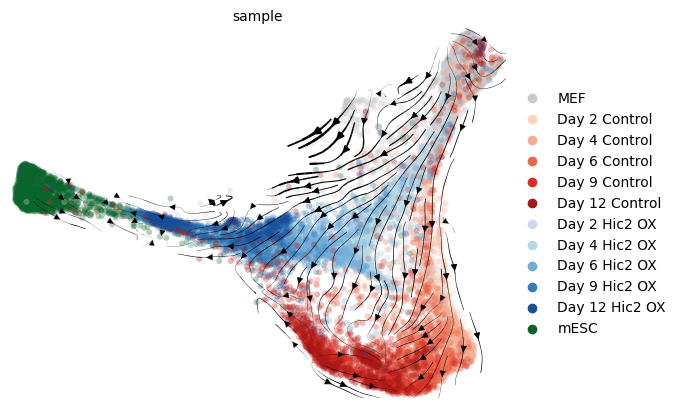

In [8]:
# Plot kernel vector field

combined_kernel.plot_projection(basis="fdl", color="sample", legend_loc="right margin")

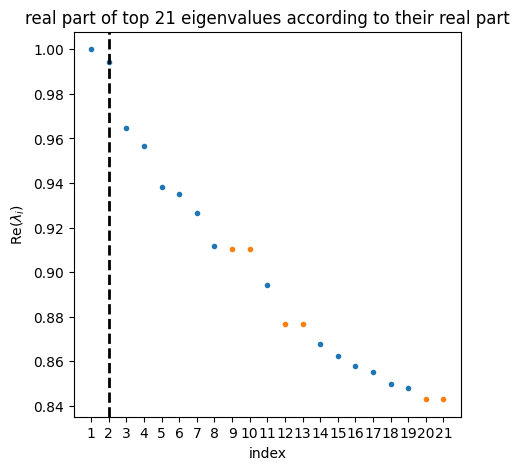

In [9]:
estimator = cellrank.estimators.GPCCA(combined_kernel)
estimator.compute_schur()
estimator.plot_spectrum(real_only=True)

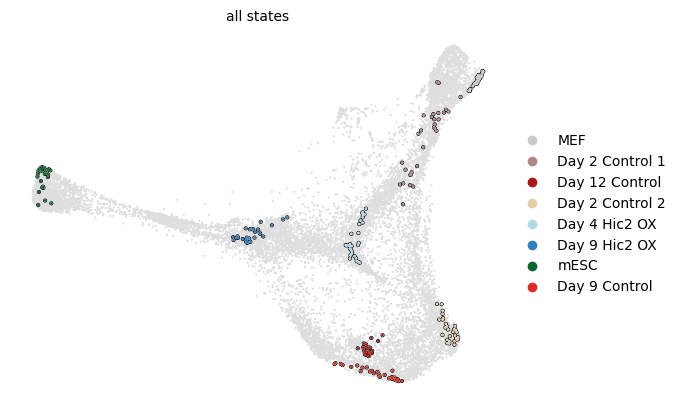

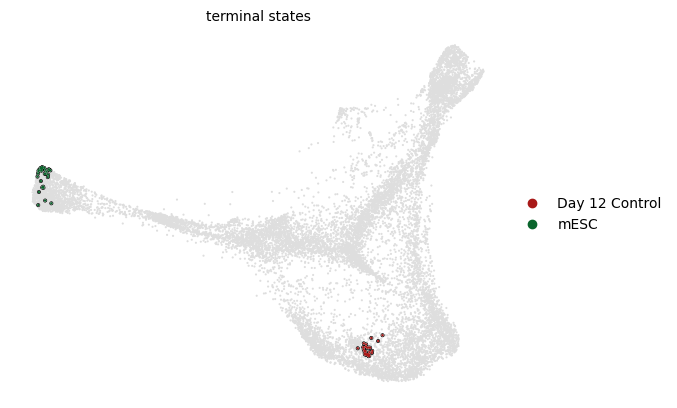

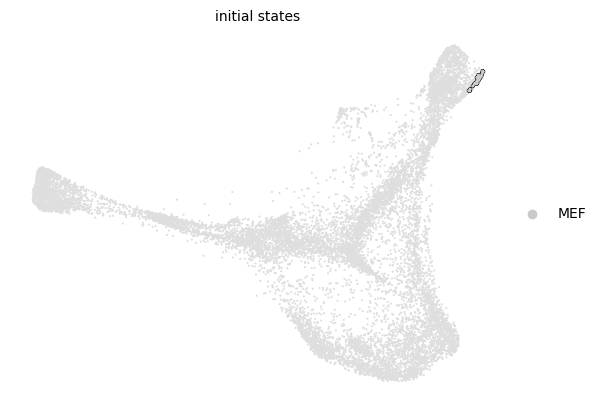

In [10]:
estimator = cellrank.estimators.GPCCA(combined_kernel)
estimator.compute_macrostates(n_states=8, cluster_key="sample")

estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states

estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states

estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)
initial_states = estimator.initial_states_memberships.names

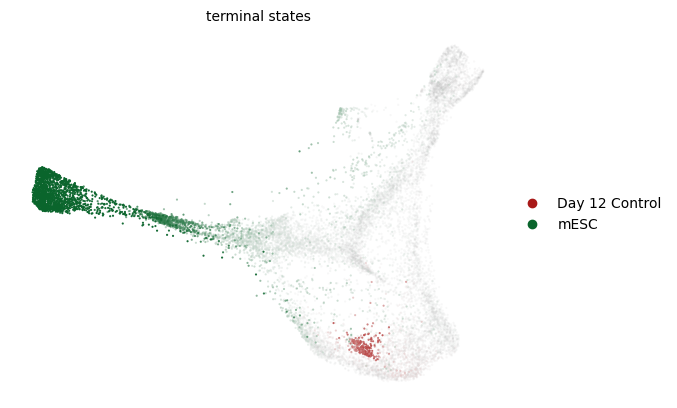

In [11]:
# Plot probability of cells belonging to the terminal states

estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=False, basis="fdl")

In [12]:
# Plot stability values. These are used to find terminal states with method="stability" and show that Day 4 control and Day 9 Hic2 OX are metastable

stability_values = estimator.coarse_T.values.diagonal()

stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)

print(stability_df)

        Macrostate  Stability
6             mESC   0.995400
2   Day 12 Control   0.971293
5    Day 9 Hic2 OX   0.968644
7    Day 9 Control   0.959729
3  Day 2 Control_2   0.943888
4    Day 4 Hic2 OX   0.943720
0              MEF   0.931374
1  Day 2 Control_1   0.913847


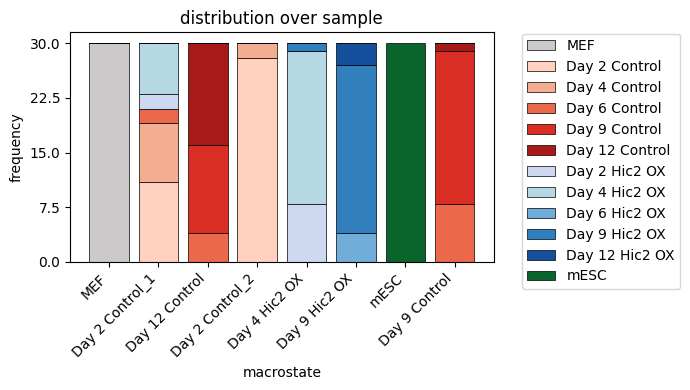

In [13]:
estimator.plot_macrostate_composition(key="sample", figsize=(7, 4))

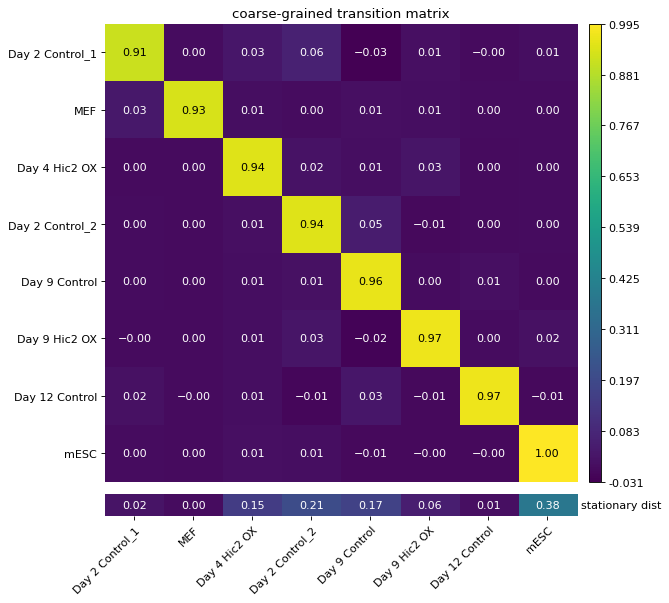

In [14]:
estimator.plot_coarse_T()

  0%|          | 0/2 [00:00<?, ?/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


  0%|          | 0/2 [00:00<?, ?/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


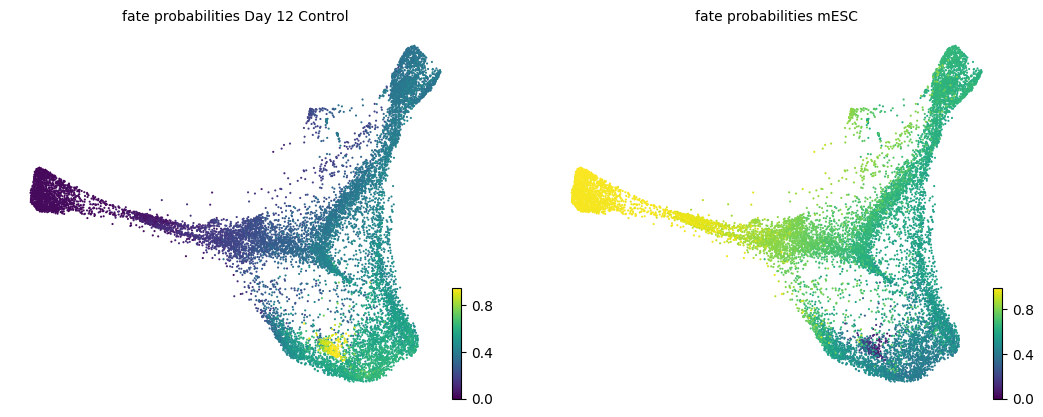

In [15]:
# Estimate fate probabilities

estimator.compute_fate_probabilities()

# Add fate probabilities to adata
for terminal_state in terminal_states:
    adata.obs[f"fate_probabilities_{terminal_state}"] = estimator.fate_probabilities[terminal_state].X.flatten()
estimator.compute_fate_probabilities()
estimator.plot_fate_probabilities(same_plot=False, basis="fdl")

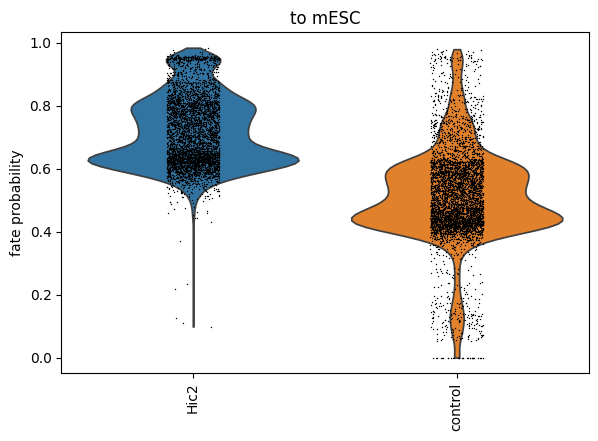

In [16]:
# Aggregate fate probabilities

cellrank.pl.aggregate_fate_probabilities(
    adata,
    mode="violin",
    lineages=["mESC"],
    cluster_key="group",
    clusters=["control", "Hic2"],
)

In [17]:
# Find driver genes for all terminal states

reprogramming_groups = ["Hic2", "control"]

driver_df = estimator.compute_lineage_drivers(
    cluster_key="group", clusters=reprogramming_groups
)
corr_columns = [state+"_corr" for state in terminal_states]

In [18]:
# Drivers for mESCs
driver_df.sort_values("mESC_corr", ascending=False).head(20)[corr_columns]

,Day 12 Control_corr,mESC_corr
gene_names,,
Rbpms2,-0.602198,0.602198
Mdk,-0.588507,0.588502
Fbxo15,-0.588007,0.588008
Folr1,-0.578954,0.578954
Utf1,-0.577189,0.577189
Apoc1,-0.566894,0.566895
Dnmt3l,-0.561225,0.561227
Gdf3,-0.558969,0.558968
Klhl13,-0.558678,0.558683


In [19]:
# Drivers for Day 12 control
driver_df.sort_values("Day 12 Control_corr", ascending=False).head(20)[corr_columns]

,Day 12 Control_corr,mESC_corr
gene_names,,
Cd24a,0.665704,-0.665721
Lmo1,0.590620,-0.590620
Crip2,0.579140,-0.579149
Ctsz,0.574493,-0.574523
Lgals7,0.573253,-0.573250
Rtn4r,0.570235,-0.570235
Tmem238,0.535727,-0.535731
S100a16,0.524972,-0.524977
Pcolce2,0.524223,-0.524220


In [20]:
# How specific genes correlate with terminal states
genes_of_interest = ["Krtdap", "Krt8", "Krt14", "Nanog", "Tet1", "Cdh1", "Ovol1", "Atf3"]
terminal_states = list(adata.obs["term_states_fwd"].dropna().unique())
corr_columns = [state+"_corr" for state in terminal_states]
driver_df.loc[genes_of_interest]

,Day 12 Control_corr,Day 12 Control_pval,Day 12 Control_qval,Day 12 Control_ci_low,Day 12 Control_ci_high,mESC_corr,mESC_pval,mESC_qval,mESC_ci_low,mESC_ci_high
gene_names,,,,,,,,,,
Krtdap,0.108337,2.136638e-26,4.756819e-26,0.088480,0.128108,-0.108331,2.149673e-26,4.785839e-26,-0.128102,-0.088474
Krt8,0.440069,0.000000e+00,0.000000e+00,0.423758,0.456094,-0.440064,0.000000e+00,0.000000e+00,-0.456089,-0.423753
Krt14,0.343130,1.014561e-267,9.467656e-267,0.325319,0.360698,-0.343126,1.029298e-267,9.605175e-267,-0.360694,-0.325315
Nanog,-0.310068,1.376463e-215,1.053179e-214,-0.328078,-0.291833,0.310066,1.385767e-215,1.060297e-214,0.291831,0.328076
Tet1,-0.484678,0.000000e+00,0.000000e+00,-0.499870,-0.469188,0.484680,0.000000e+00,0.000000e+00,0.469190,0.499872
Cdh1,0.308107,1.038062e-212,7.793268e-212,0.289848,0.326142,-0.308107,1.038442e-212,7.796122e-212,-0.326142,-0.289848
Ovol1,0.442960,0.000000e+00,0.000000e+00,0.426700,0.458933,-0.442961,0.000000e+00,0.000000e+00,-0.458934,-0.426701
Atf3,0.337604,1.612167e-258,1.463408e-257,0.319719,0.355249,-0.337606,1.603255e-258,1.455318e-257,-0.355250,-0.319720


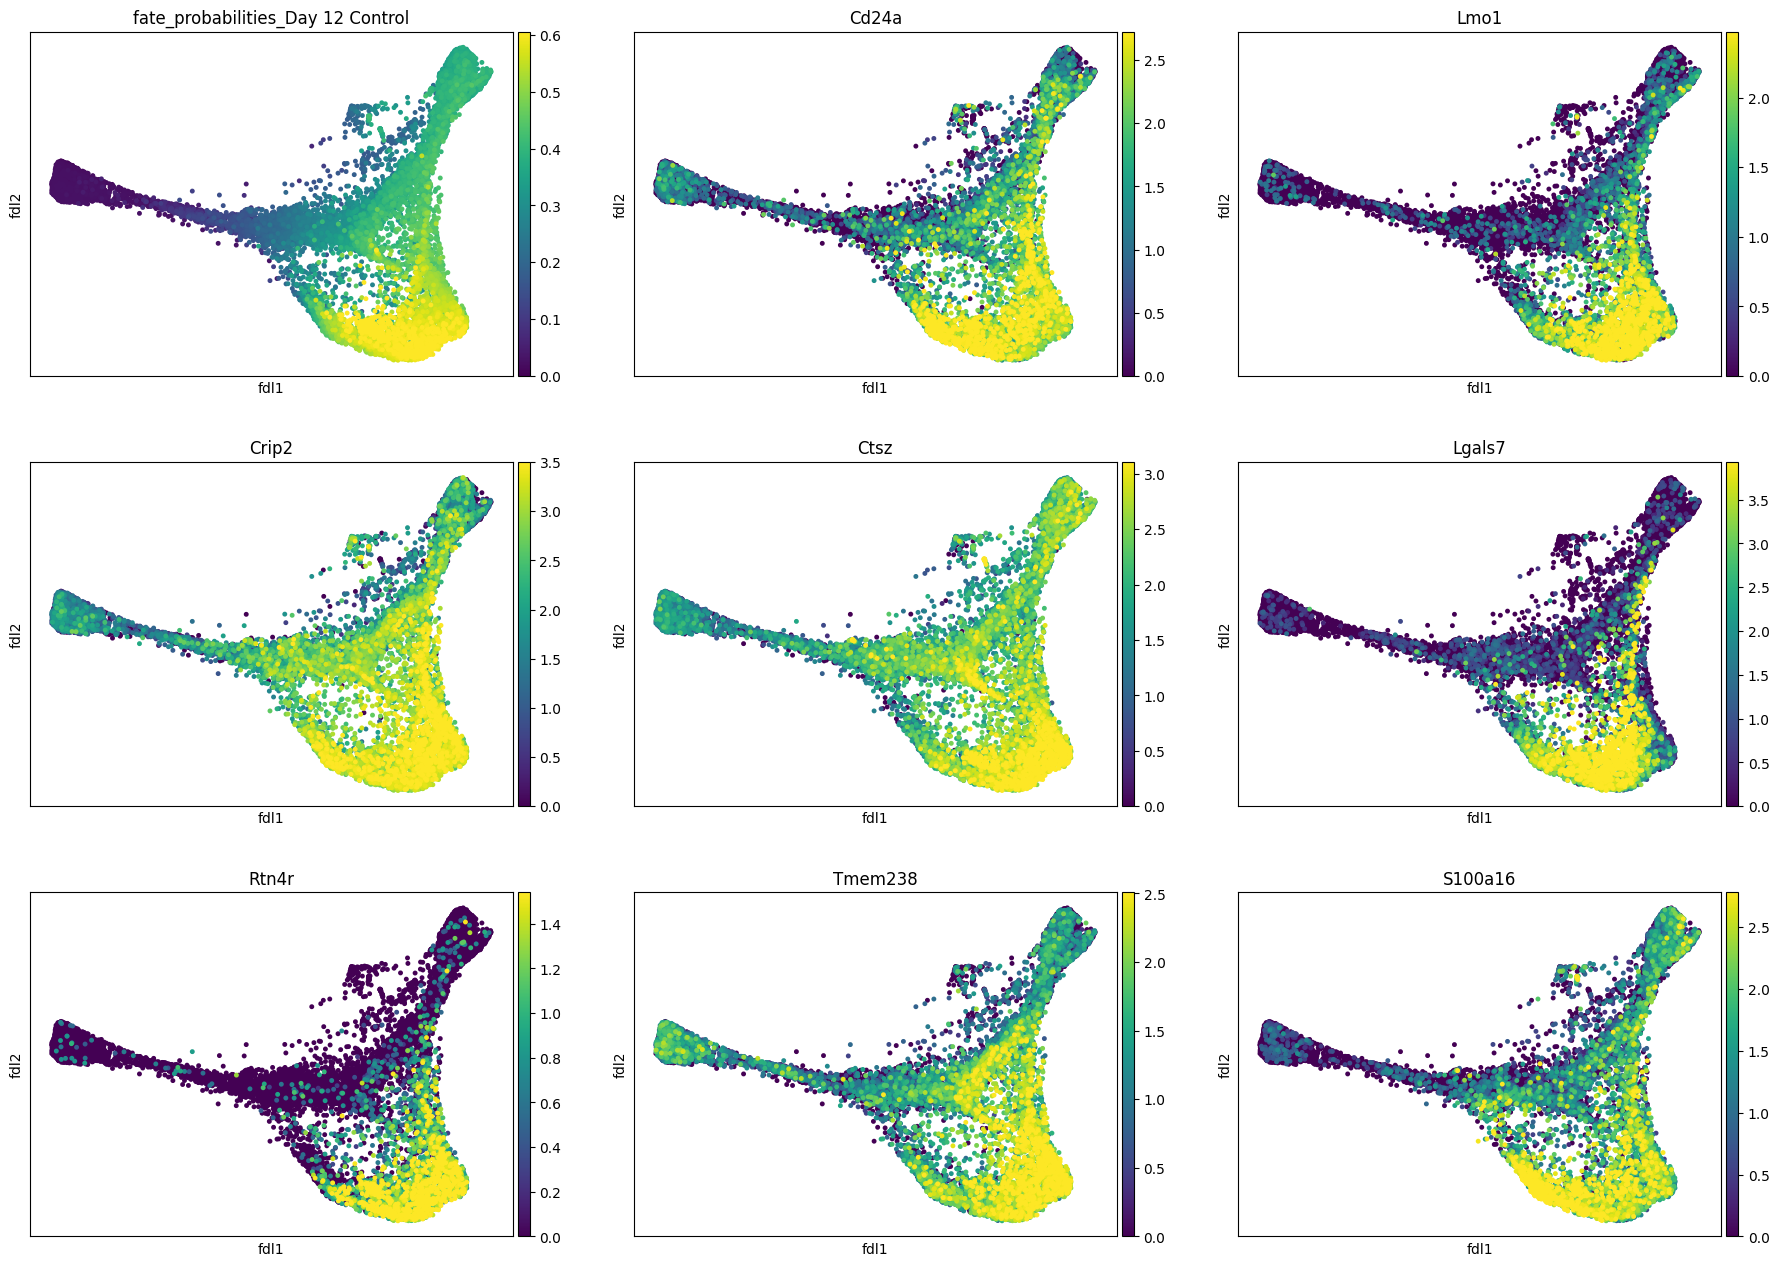

In [22]:
# Visualize driver genes for day 12 control

terminal_state = "Day 12 Control"
scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=[f"fate_probabilities_{terminal_state}"] + list(driver_df.sort_values(f"{terminal_state}_corr", ascending=False).index[:8]),
    color_map="viridis",
    s=50,
    ncols=3,
    vmax="p96",
)

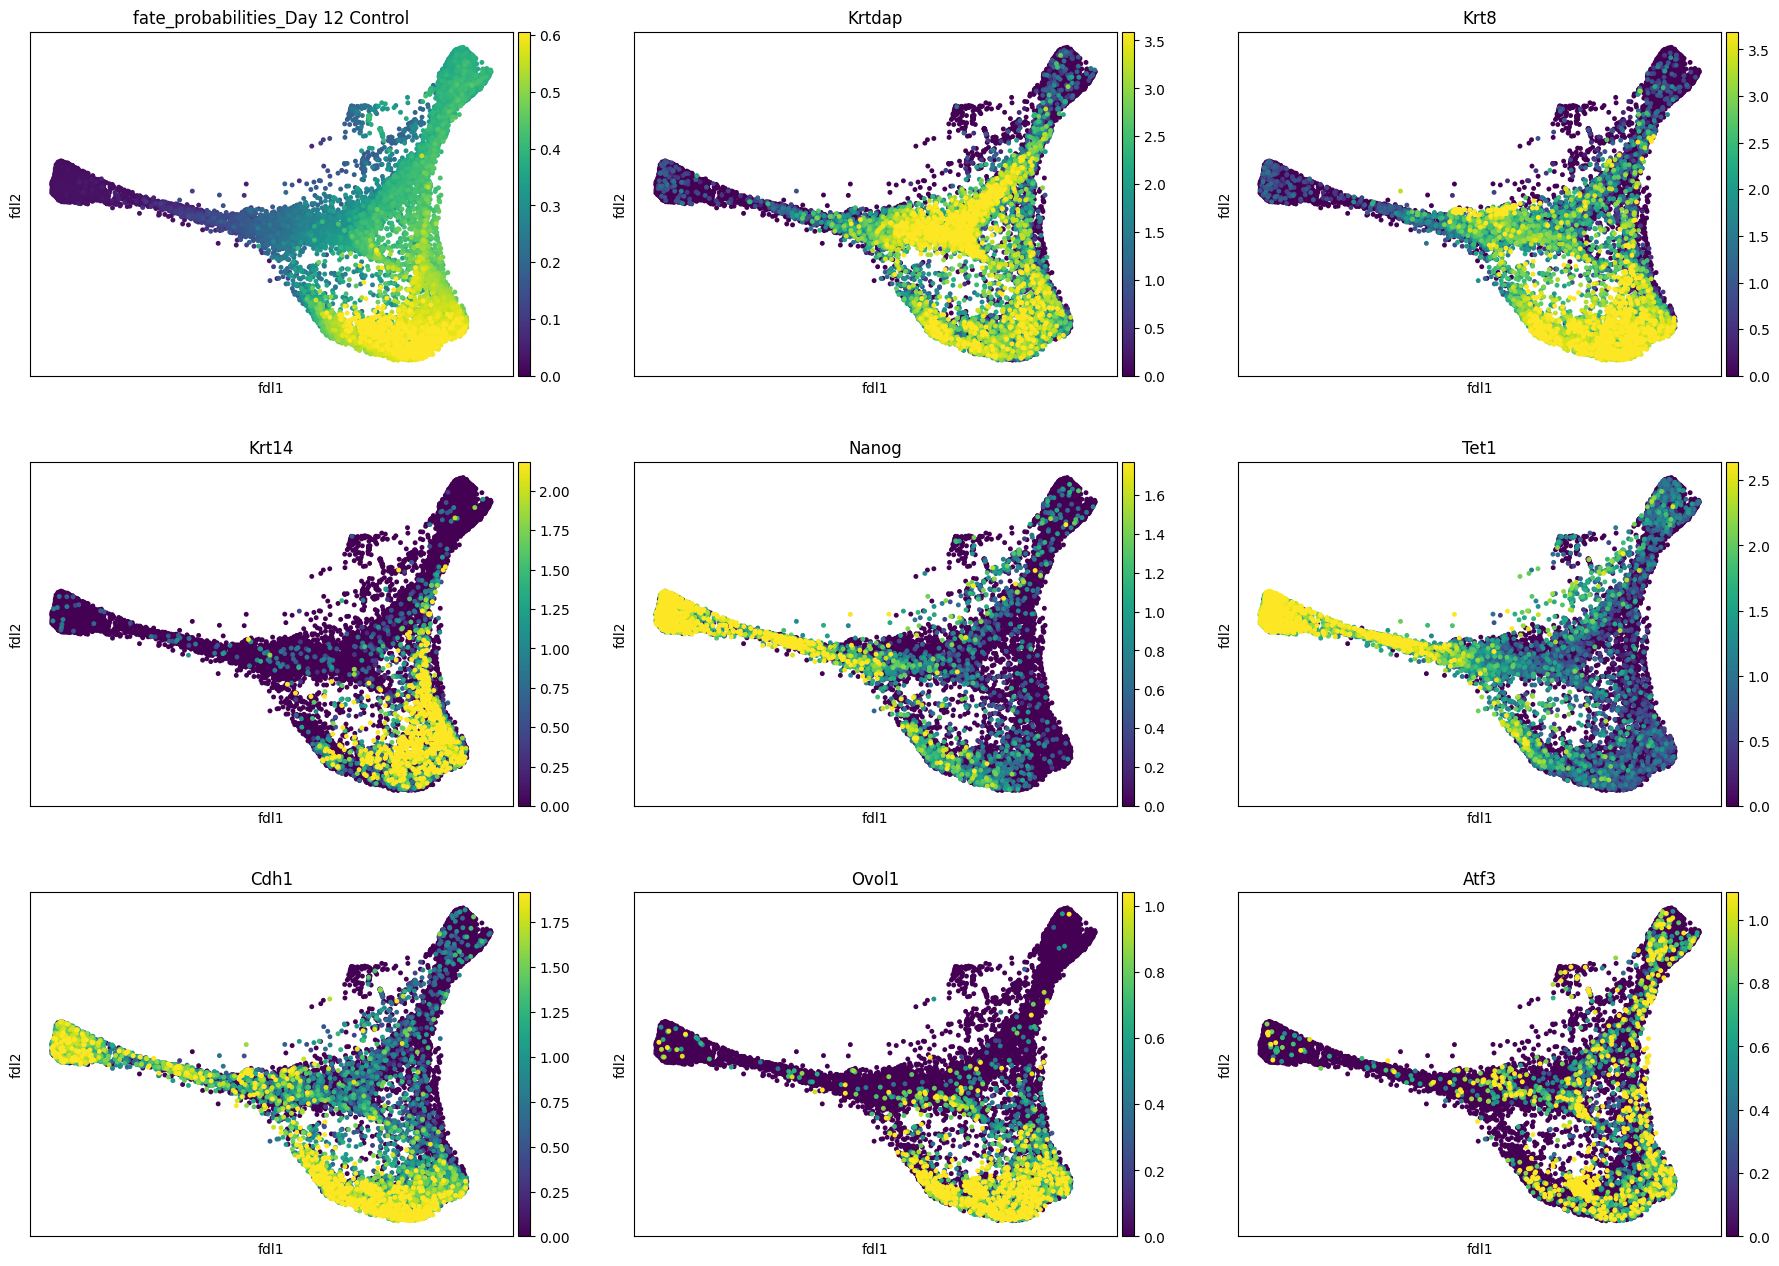

In [23]:
# Visualize genes of interest

terminal_state = "Day 12 Control"
scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=[f"fate_probabilities_{terminal_state}"] + genes_of_interest,
    color_map="viridis",
    s=50,
    ncols=3,
    vmax="p96",
)

In [24]:
# Gene expression over time

# Create model
model = cellrank.models.GAMR(adata, n_knots=6, smoothing_penalty=10.0) # GAMR can be used instead to have the R model

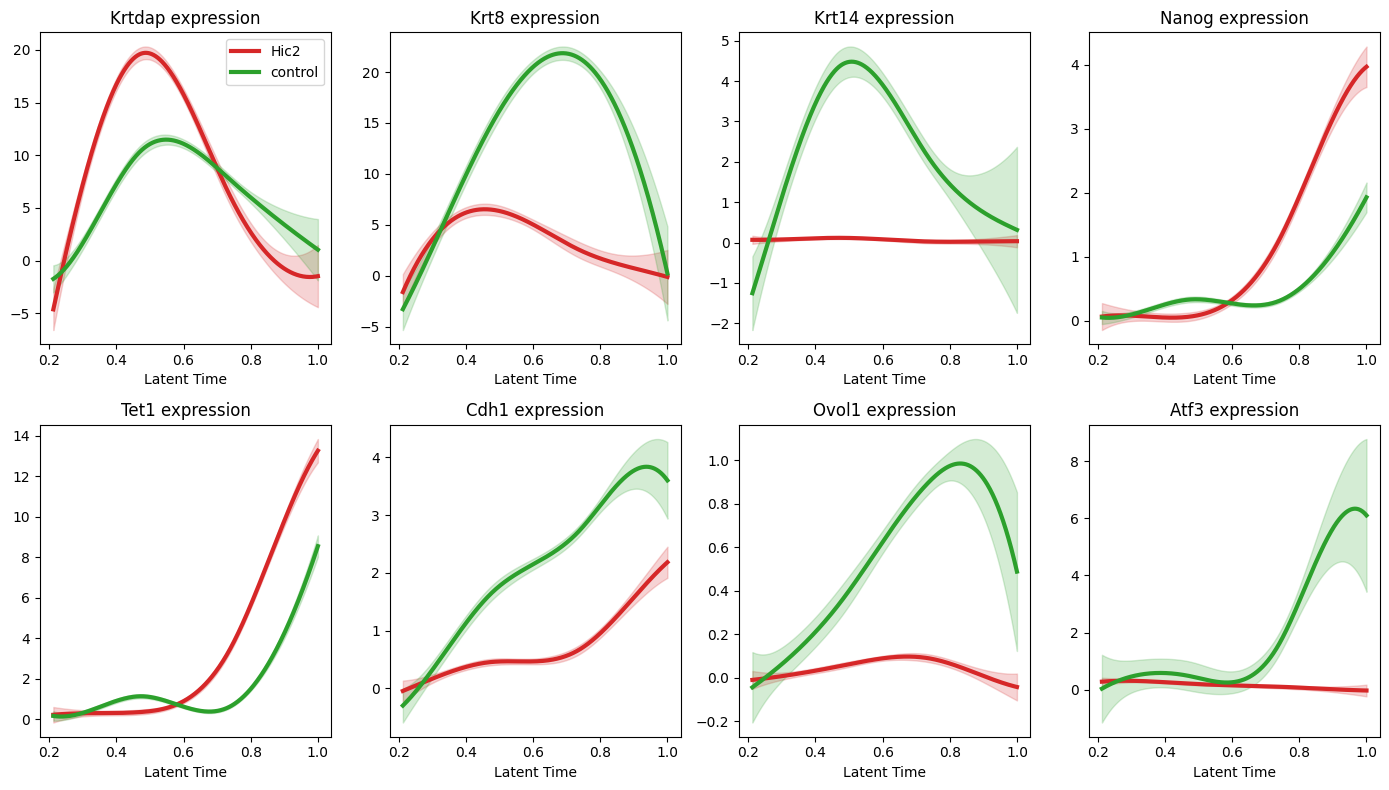

In [25]:
# Trends independent of trajectory

import pygam

def plot_grouped_gene_trend(adata, genes, group_key="group", time_key="latent_time", layer="Ms", groups=None, columns=4, figure_width=14, plot_height=4):
    """
    Plots smoothed gene expression using Generalized Additive Models (GAMs).
    This provides true smooth local regression with confidence intervals.
    """

    number_of_genes = len(genes)
    number_of_columns = min(columns, number_of_genes)
    
    # Calculate rows
    rows = (number_of_genes + number_of_columns - 1) // number_of_columns
    
    figure, axes = pyplot.subplots(rows, number_of_columns)
    figure.set_figwidth(figure_width)
    figure.set_figheight(plot_height * rows)

    # Handle single gene case (axes is not an array) and 1D array case
    if number_of_genes == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()

    # Define colors for groups
    unique_groups = adata.obs[group_key].unique()
    palette = seaborn.color_palette("tab10", n_colors=len(unique_groups))
    color_map = dict(zip(unique_groups, palette))

    for gene_index, gene in enumerate(genes):
        axis = axes_flat[gene_index]
        
        # Fetch expression data
        expr_data = adata[:, gene].layers[layer]
        if hasattr(expr_data, "toarray"):
            expr_data = expr_data.toarray()
        expr_data = expr_data.flatten()
        
        # Create DataFrame
        df = pandas.DataFrame({
            "Latent Time": adata.obs[time_key],
            "Expression": expr_data,
            "Group": adata.obs[group_key]
        })
        
        # Determine which groups to plot
        if groups is None:
            # If no specific list, plot all groups found in the data
            plot_groups = df["Group"].unique()
        else:
            plot_groups = groups

        # Loop through each group and fit a GAM
        for group in plot_groups:
            group_data = df[df["Group"] == group]
            
            # Skip empty groups
            if len(group_data) < 10:
                continue

            # Prepare X and y for pygam (X must be 2D array)
            X = group_data["Latent Time"].values.reshape(-1, 1)
            y = group_data["Expression"].values
            
            # Fit LinearGAM using a Spline term s(0)
            # n_splines=20 gives good flexibility (smoothness)
            gam = pygam.LinearGAM(pygam.s(0, n_splines=6)).fit(X, y)
            
            # Generate a smooth grid for plotting lines
            X_grid = numpy.linspace(X.min(), X.max(), 500)
            
            # Predict values and confidence intervals
            y_pred = gam.predict(X_grid)
            confidence_intervals = gam.confidence_intervals(X_grid, width=0.95)
            
            # Plot Line
            color = color_map[group]
            axis.plot(X_grid, y_pred, label=group, color=color, linewidth=3)
            
            # Plot Confidence Interval (Fill)
            axis.fill_between(
                X_grid, 
                confidence_intervals[:, 0], 
                confidence_intervals[:, 1], 
                color=color, 
                alpha=0.2 # Transparency of CI
            )

        axis.set_title(f"{gene} expression")
        axis.set_xlabel("Latent Time")
        
        # Add legend only to the first plot to avoid clutter
        if gene_index == 0:
            axis.legend()

    # Clean up empty subplots
    for i in range(number_of_genes, len(axes_flat)):
        axes_flat[i].axis('off')

    pyplot.tight_layout()
    pyplot.show()

# Example usage
plot_grouped_gene_trend(
    adata, 
    genes_of_interest, 
    group_key="group", 
    layer="spliced", 
    groups=["Hic2", "control"]
)

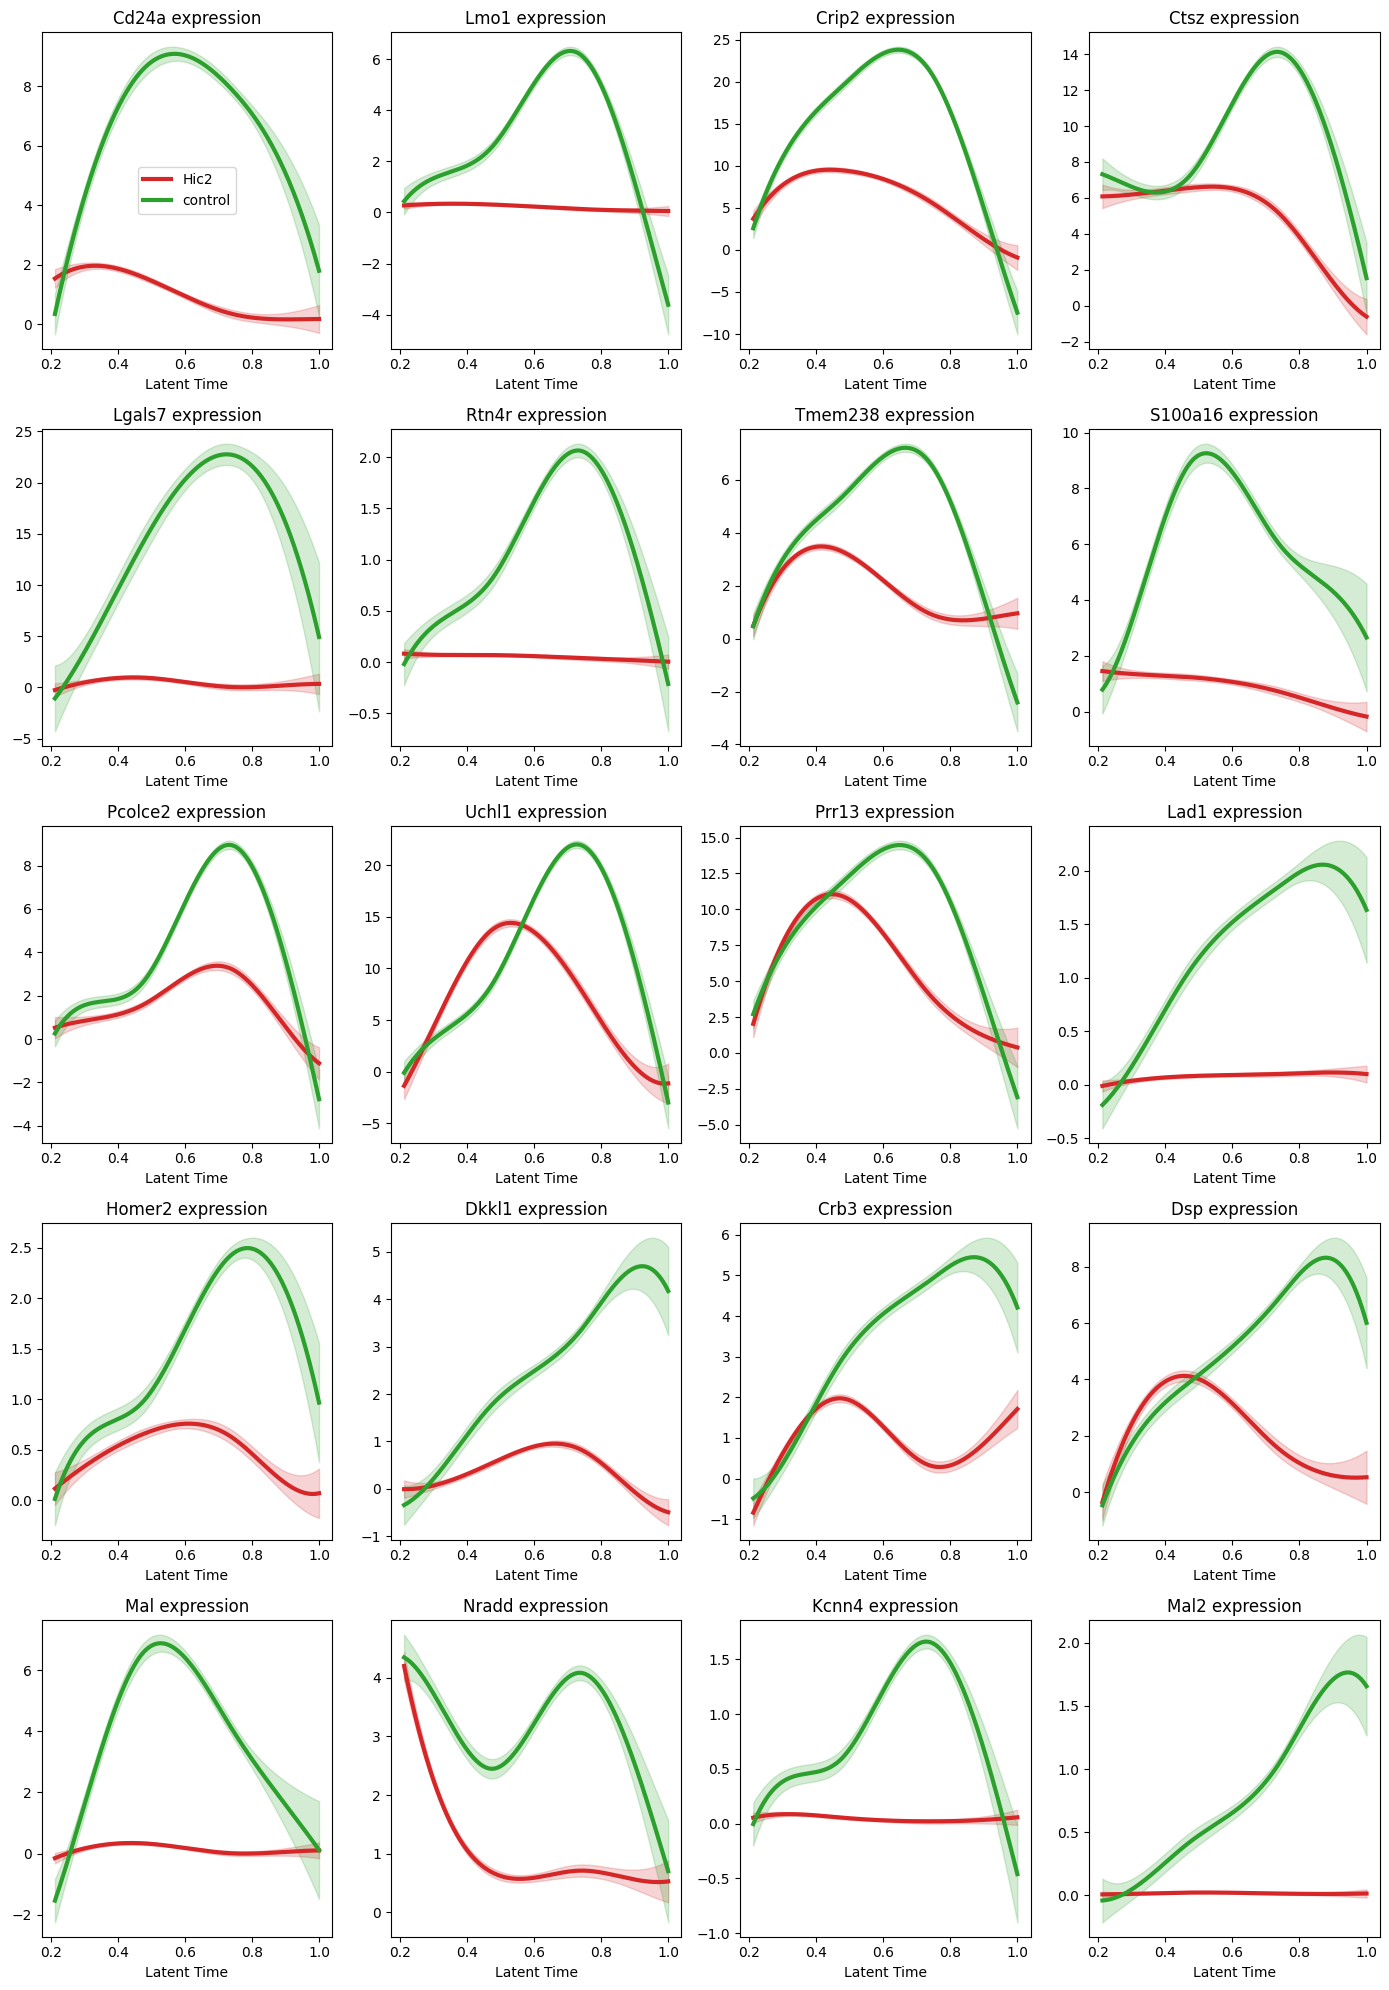

In [26]:
# Expression of drivers
control_driver_genes = driver_df.sort_values(f"Day 12 Control_corr", ascending=False).head(20).index

plot_grouped_gene_trend(
    adata, 
    control_driver_genes, 
    group_key="group", 
    layer="spliced", 
    groups=["Hic2", "control"]
)

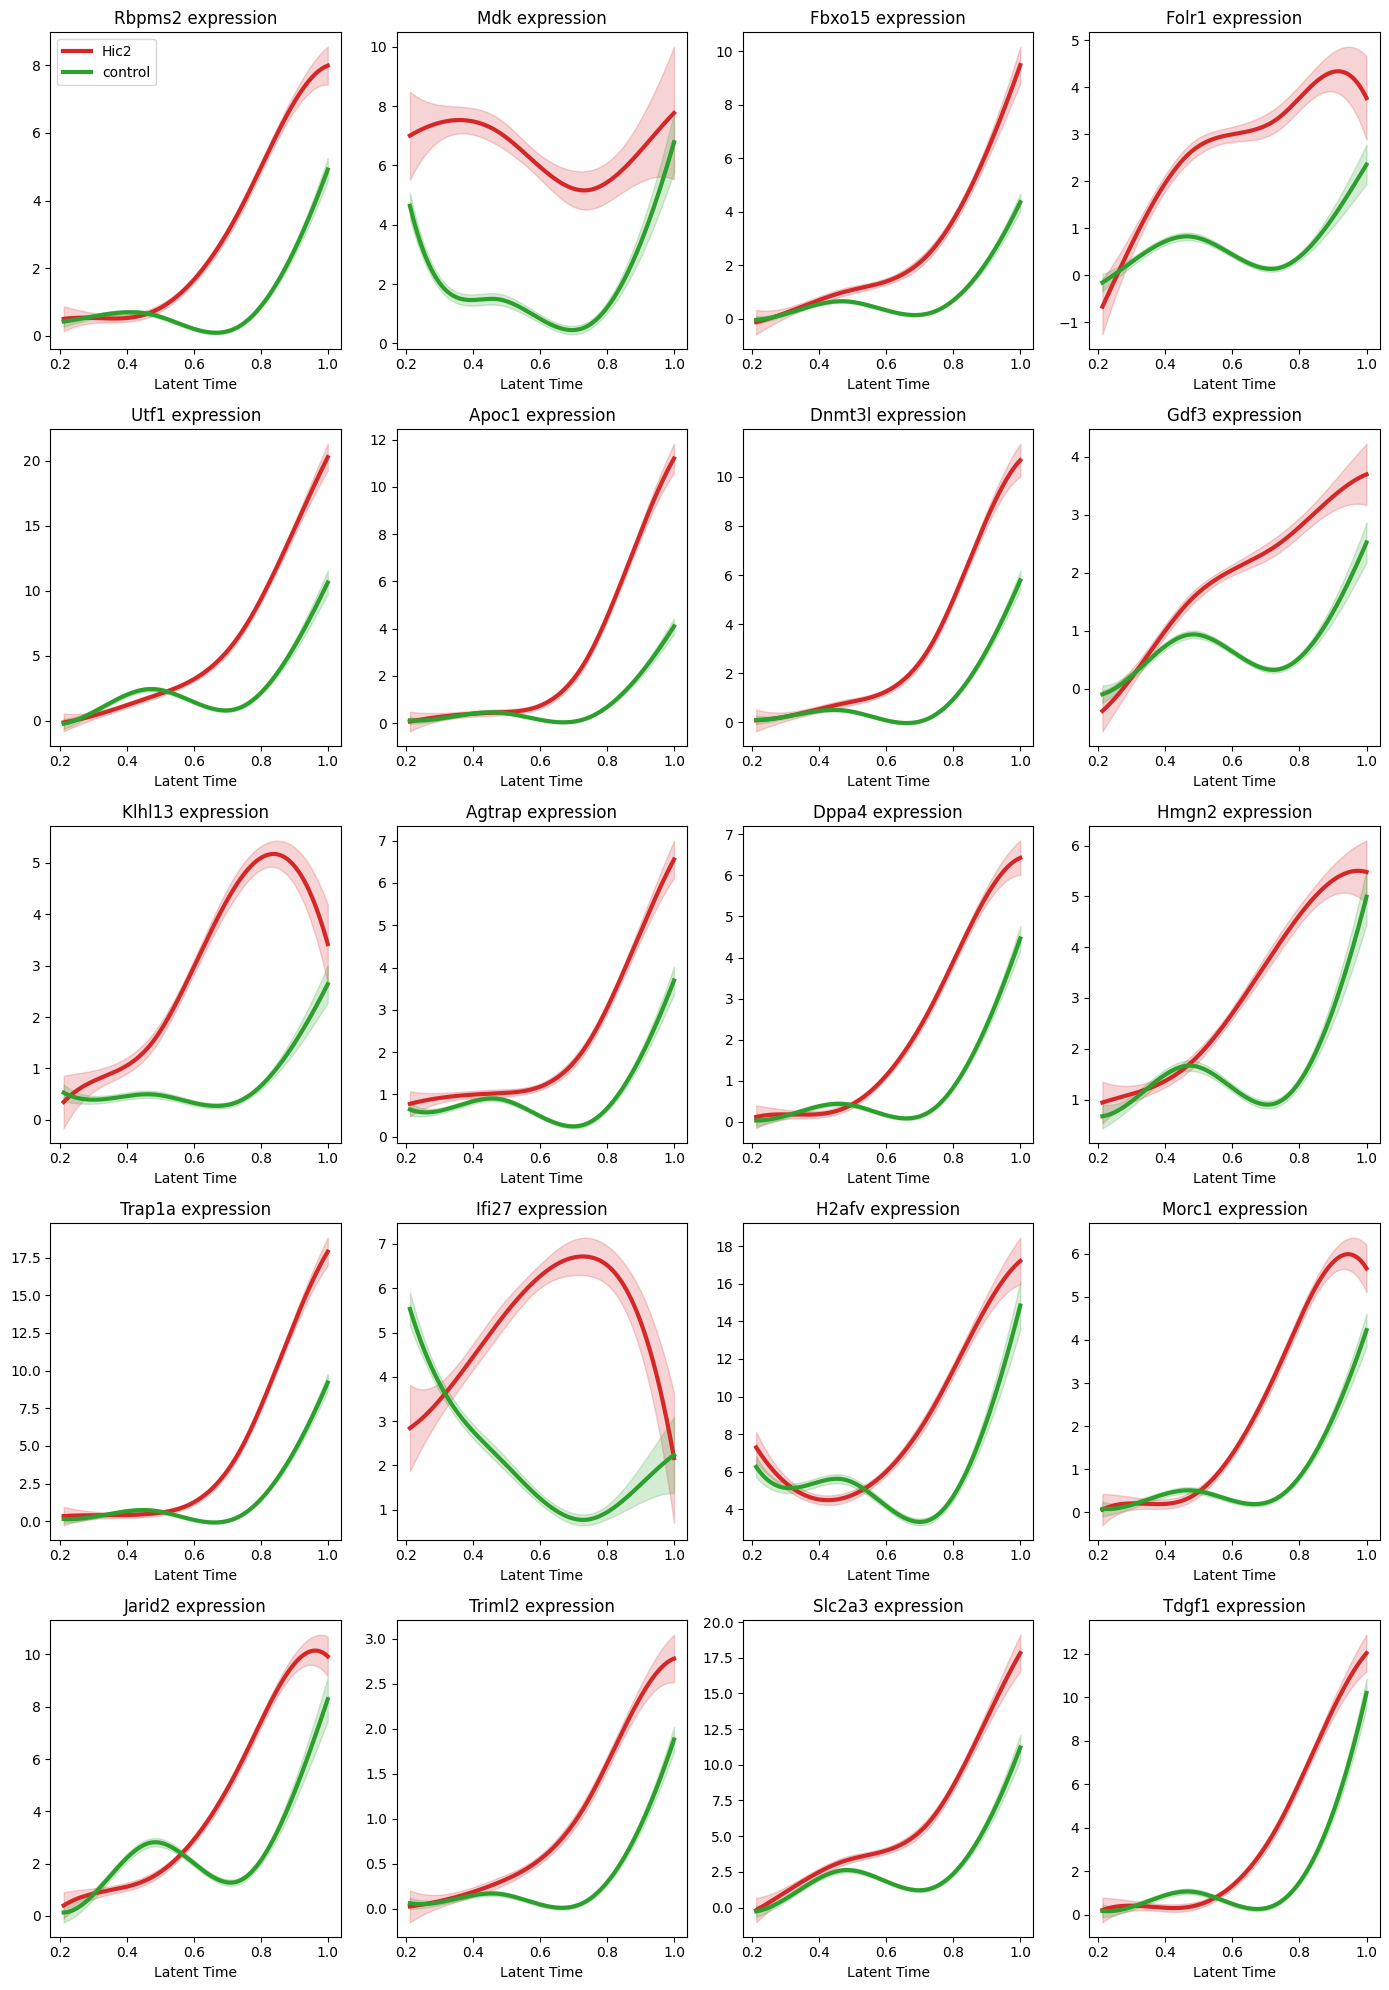

In [27]:
# Expression of reprogramming drivers
mesc_driver_genes = driver_df.sort_values(f"Day 12 Control_corr", ascending=True).head(20).index

plot_grouped_gene_trend(
    adata, 
    mesc_driver_genes, 
    group_key="group", 
    layer="spliced", 
    groups=["Hic2", "control"]
)

  0%|          | 0/10 [00:00<?, ?gene/s]

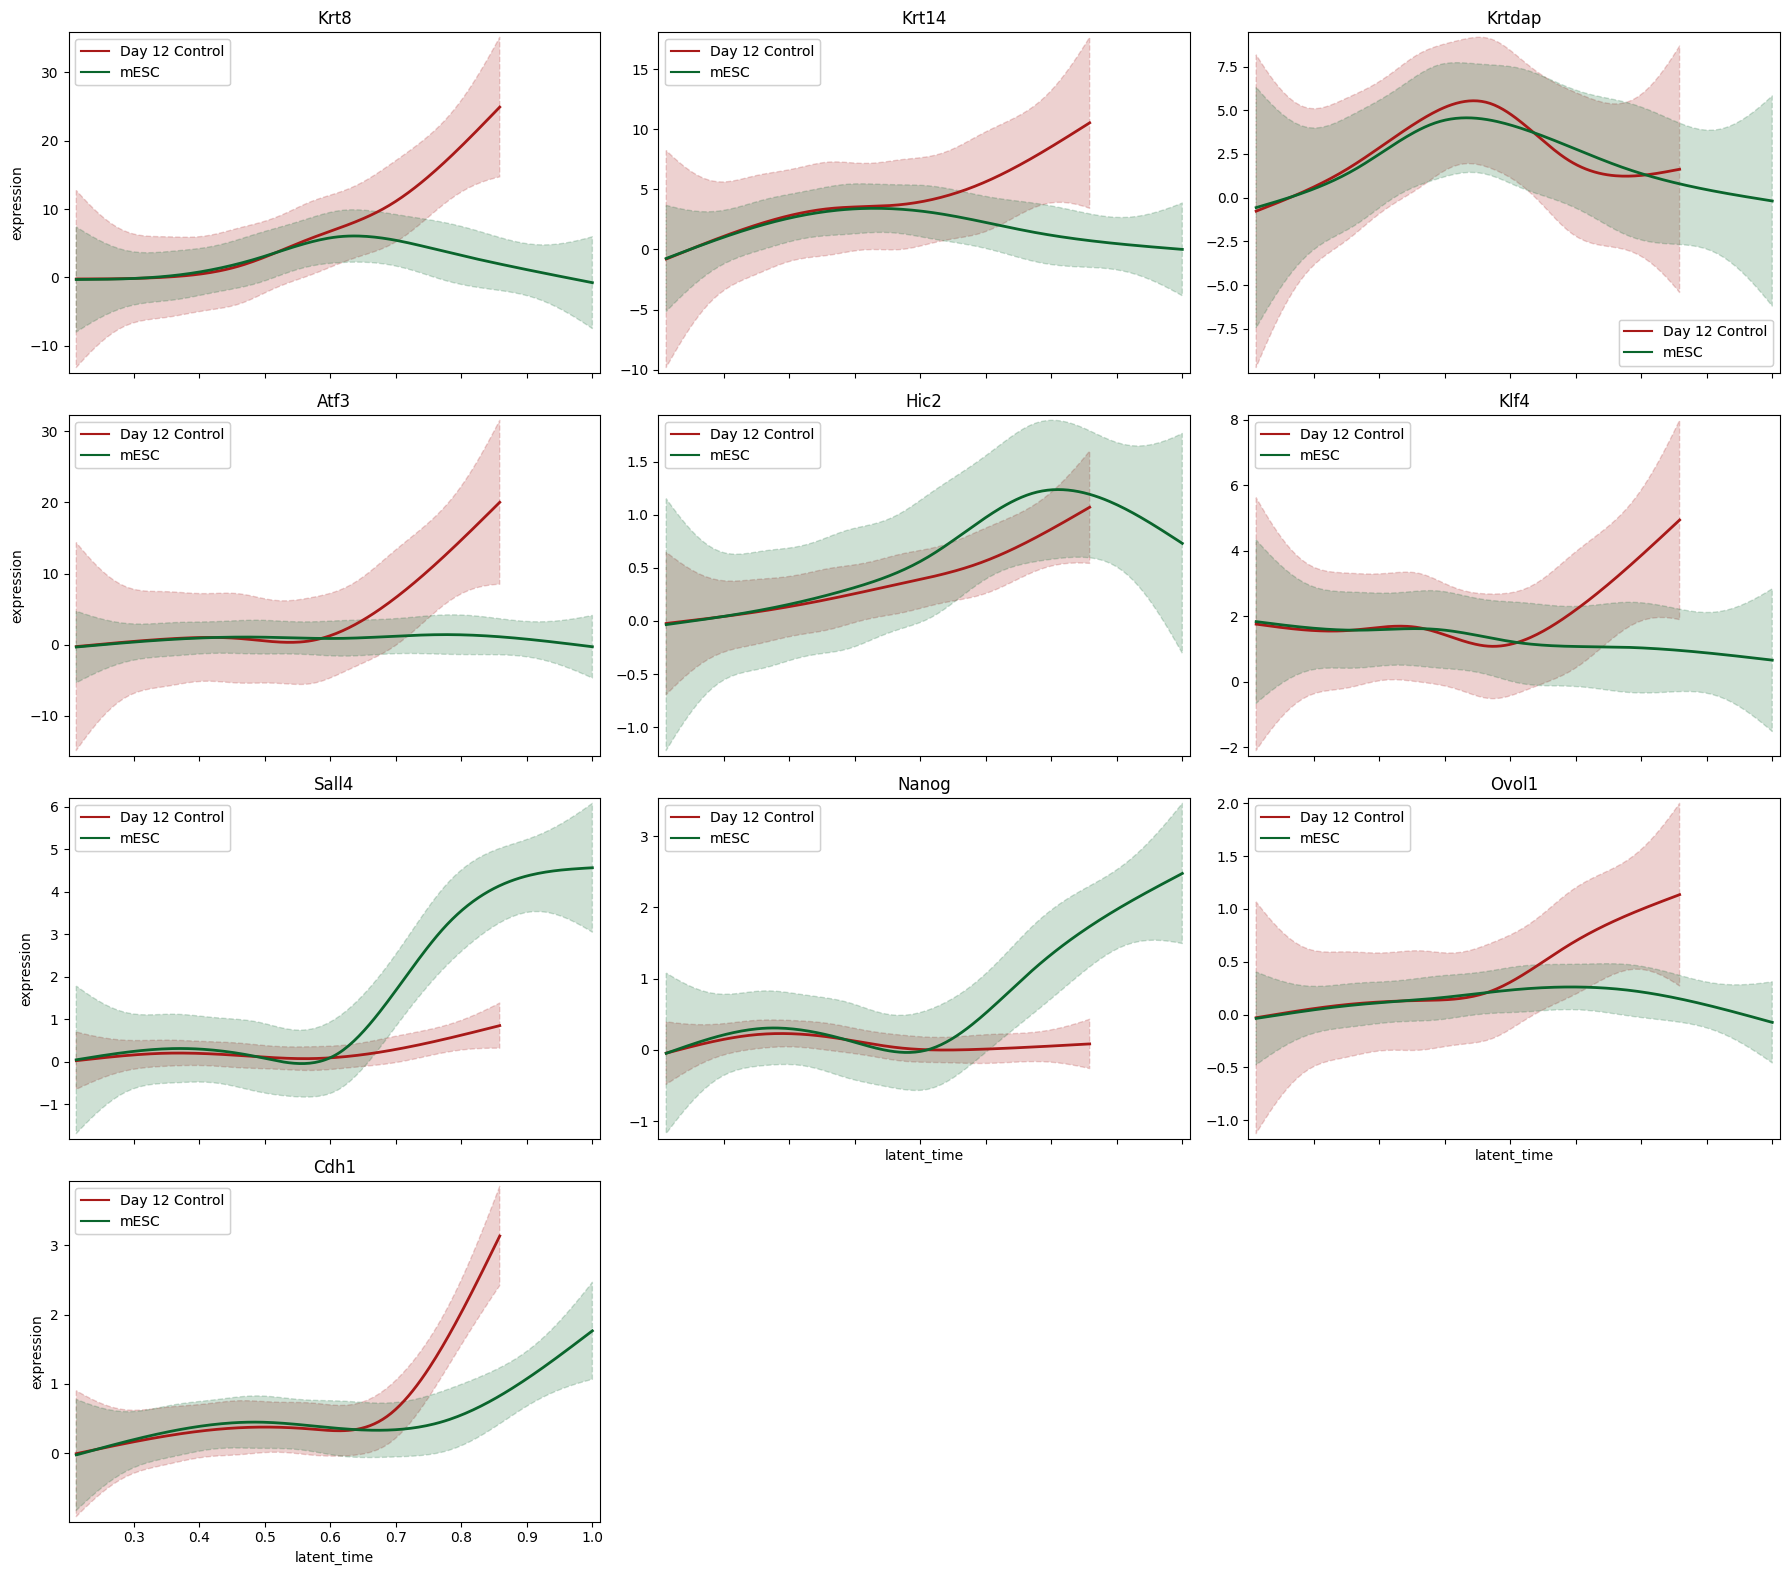

In [28]:
# Control and Hic2 group trends

trend_genes = ["Krt8", "Krt14", "Krtdap", "Atf3", "Hic2", "Klf4", "Sall4", "Nanog", "Ovol1", "Cdh1"]
reprogramming_group_indices = (adata.obs["group"] == "control") | (adata.obs["group"] == "Hic2")

model = cellrank.models.GAMR(adata[reprogramming_group_indices], n_knots=6, smoothing_penalty=10.0) # GAMR can be used instead to have the R model

cellrank.pl.gene_trends(
    adata[reprogramming_group_indices],
    model=model,
    genes=trend_genes,
    data_key="spliced",
    same_plot=True,
    ncols=3,
    time_key="latent_time",
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)


  0%|          | 0/20 [00:00<?, ?gene/s]

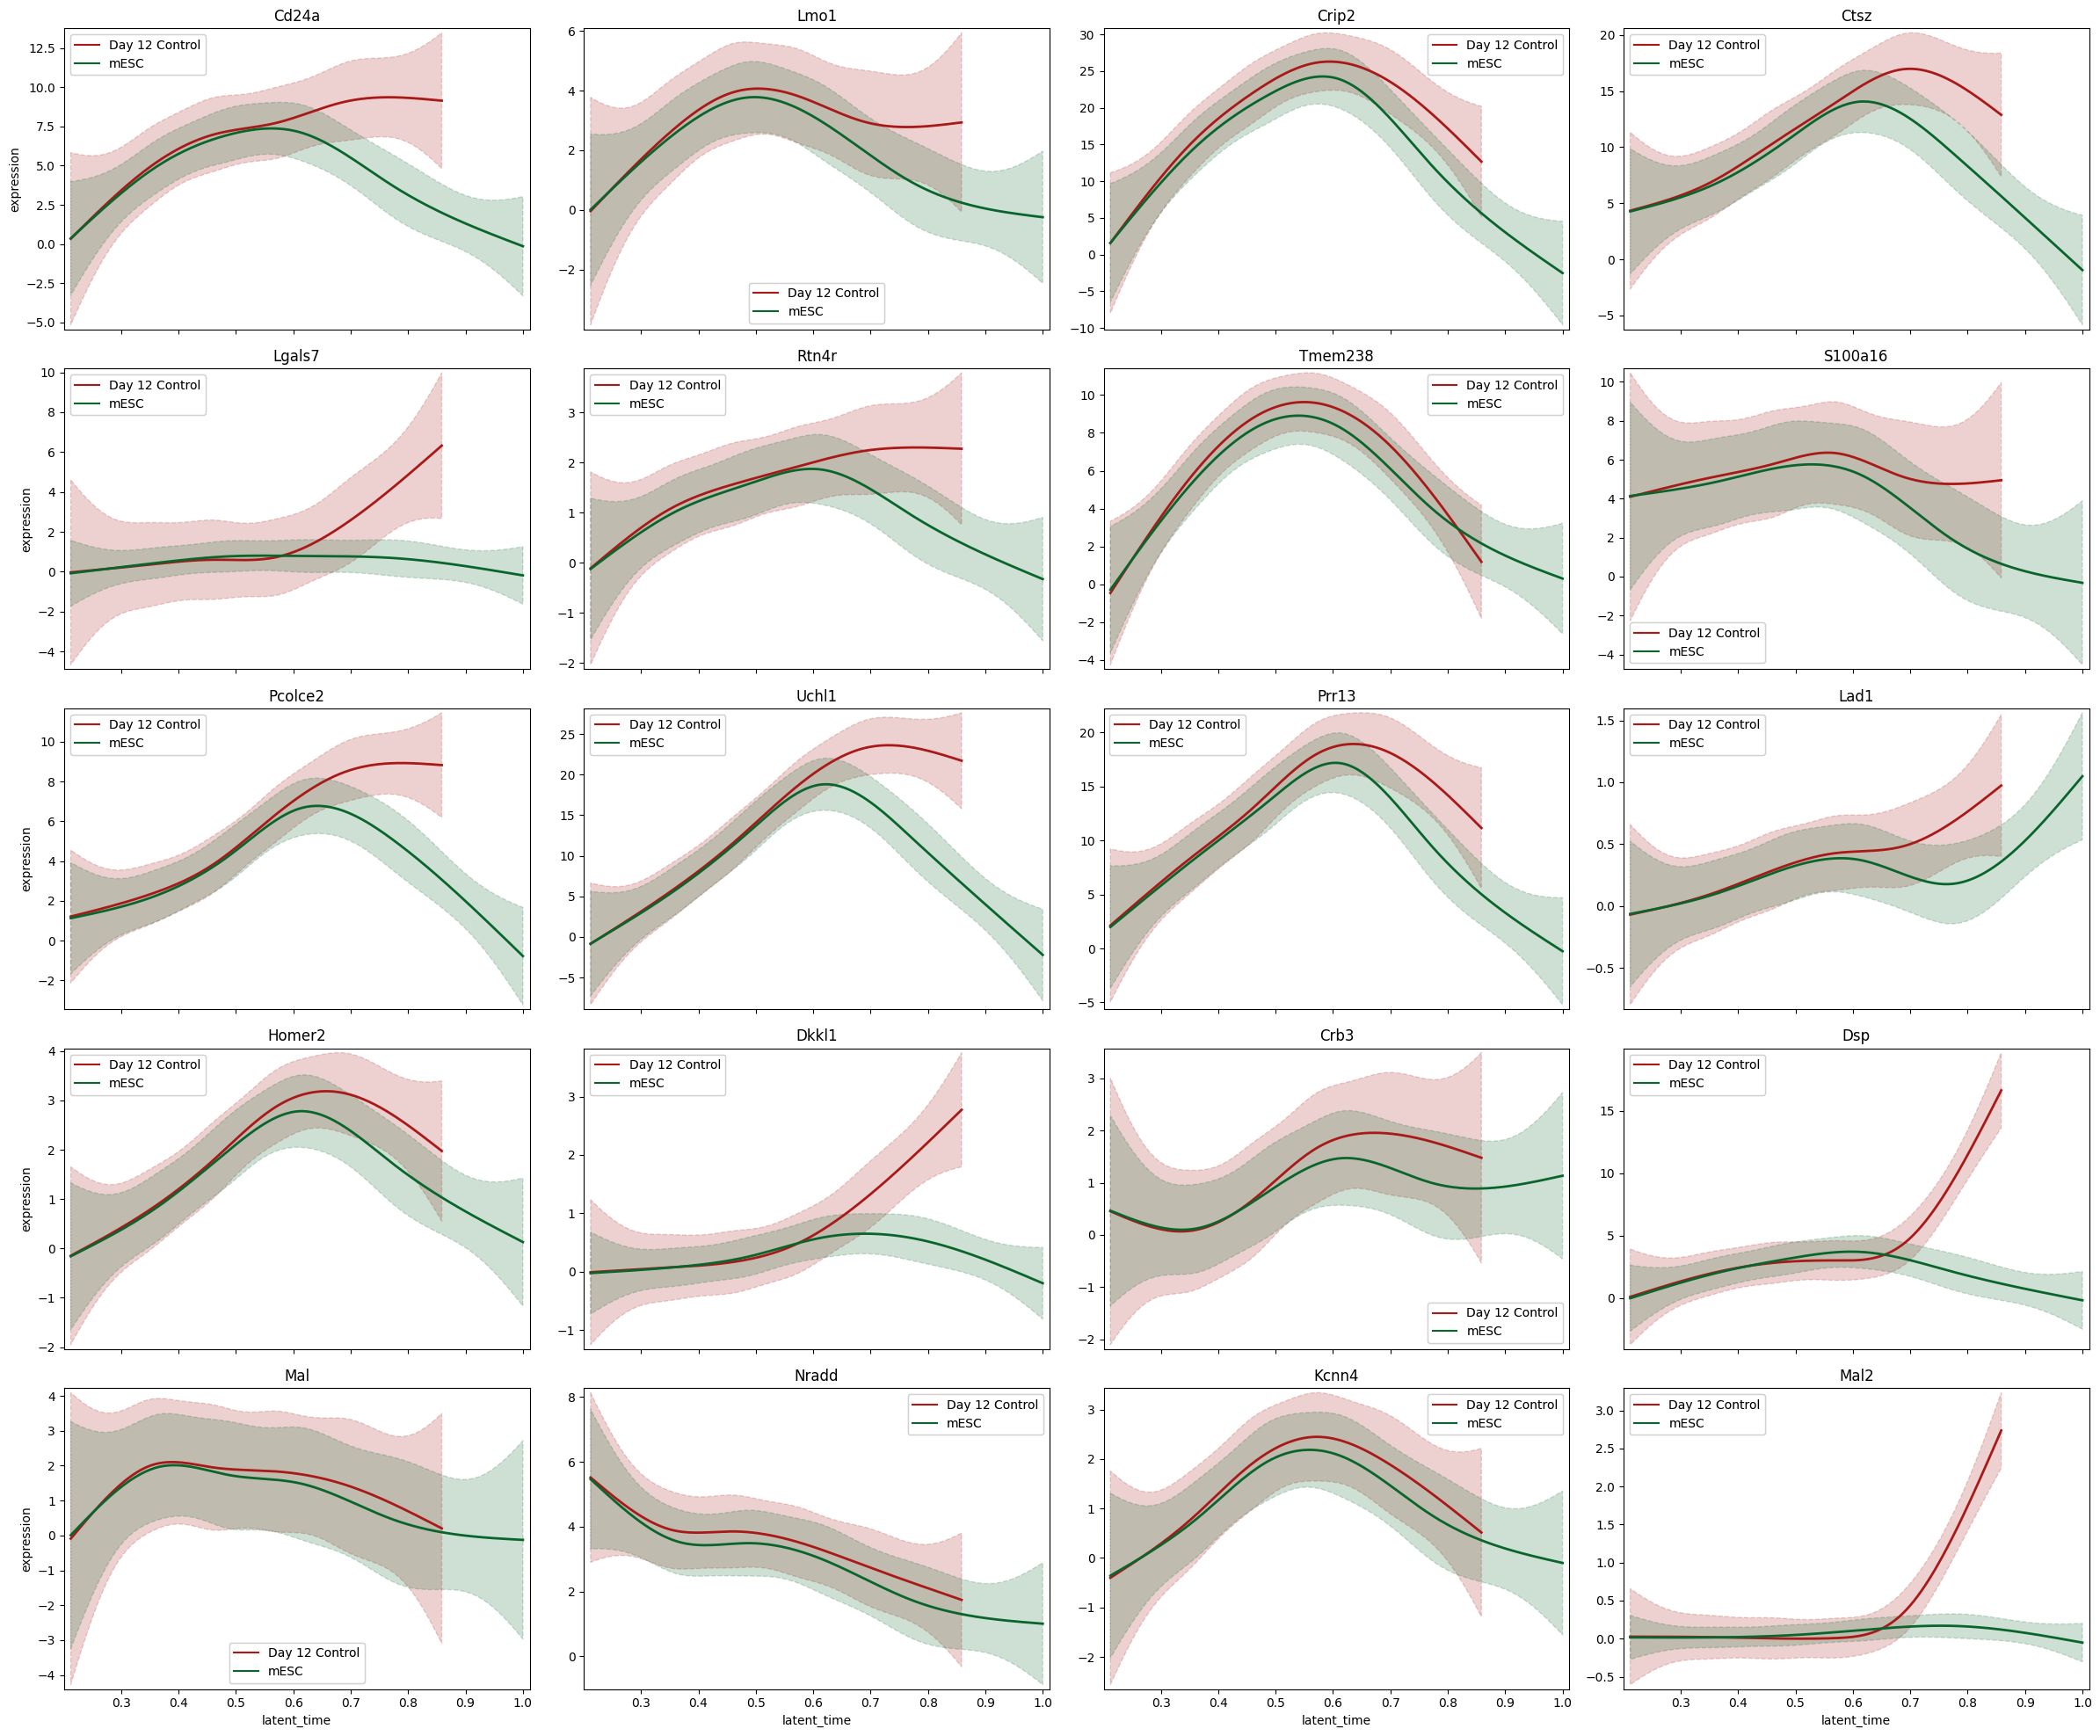

In [32]:
# The 20 strongest drivers of dead end in only control and Hic2

reprogramming_group_indices = (adata.obs["group"] == "control") | (adata.obs["group"] == "Hic2")

model = cellrank.models.GAMR(adata[reprogramming_group_indices], n_knots=6, smoothing_penalty=10.0)

dead_end = "Day 12 Control"
cellrank.pl.gene_trends(
    adata[reprogramming_group_indices],
    model=model,
    genes=driver_df.sort_values(f"{dead_end}_corr", ascending=False).head(20).index,
    data_key="spliced",
    same_plot=True,
    ncols=4,
    time_key="latent_time",
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)


  0%|          | 0/20 [00:00<?, ?gene/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


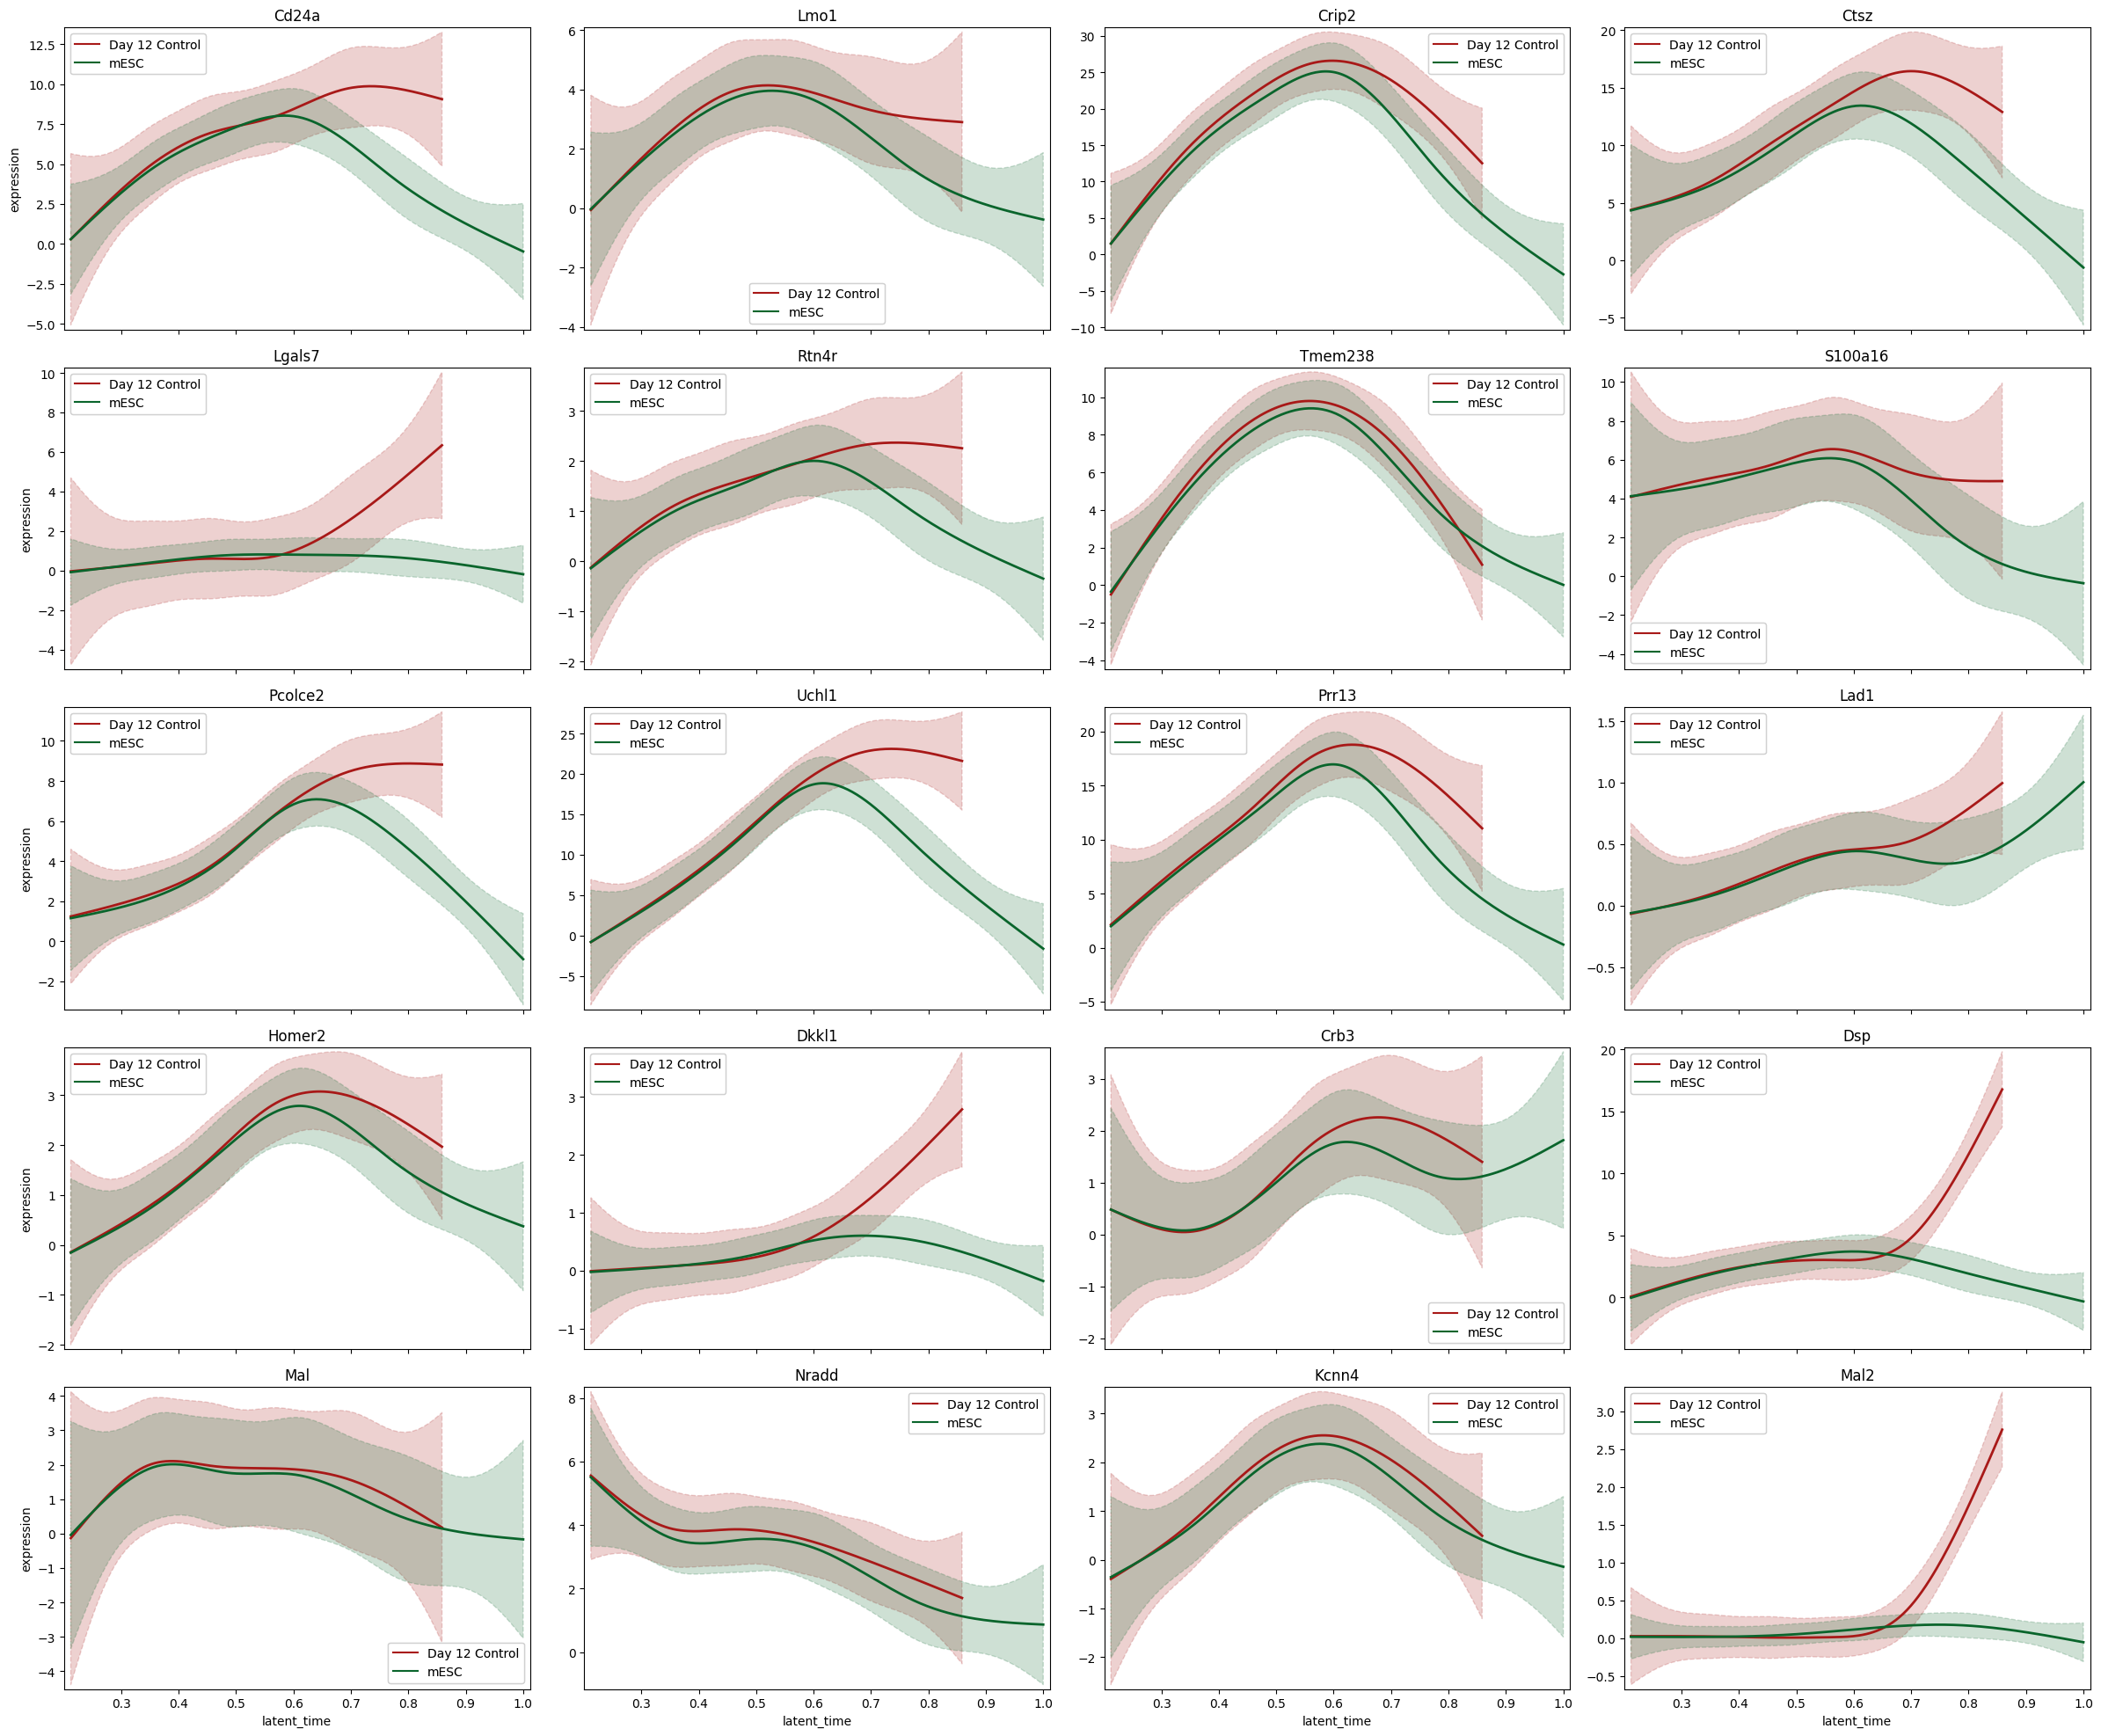

In [34]:
# Drivers with only control

model = cellrank.models.GAMR(adata[adata.obs["group"] == "control"], n_knots=6, smoothing_penalty=10.0)
control_indices = adata.obs["group"] == "control"

dead_end = "Day 12 Control"
cellrank.pl.gene_trends(
    adata[control_indices],
    model=model,
    genes=driver_df.sort_values(f"{dead_end}_corr", ascending=False).head(20).index,
    data_key="spliced",
    same_plot=True,
    ncols=4,
    time_key="latent_time",
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)


  0%|          | 0/20 [00:00<?, ?gene/s]

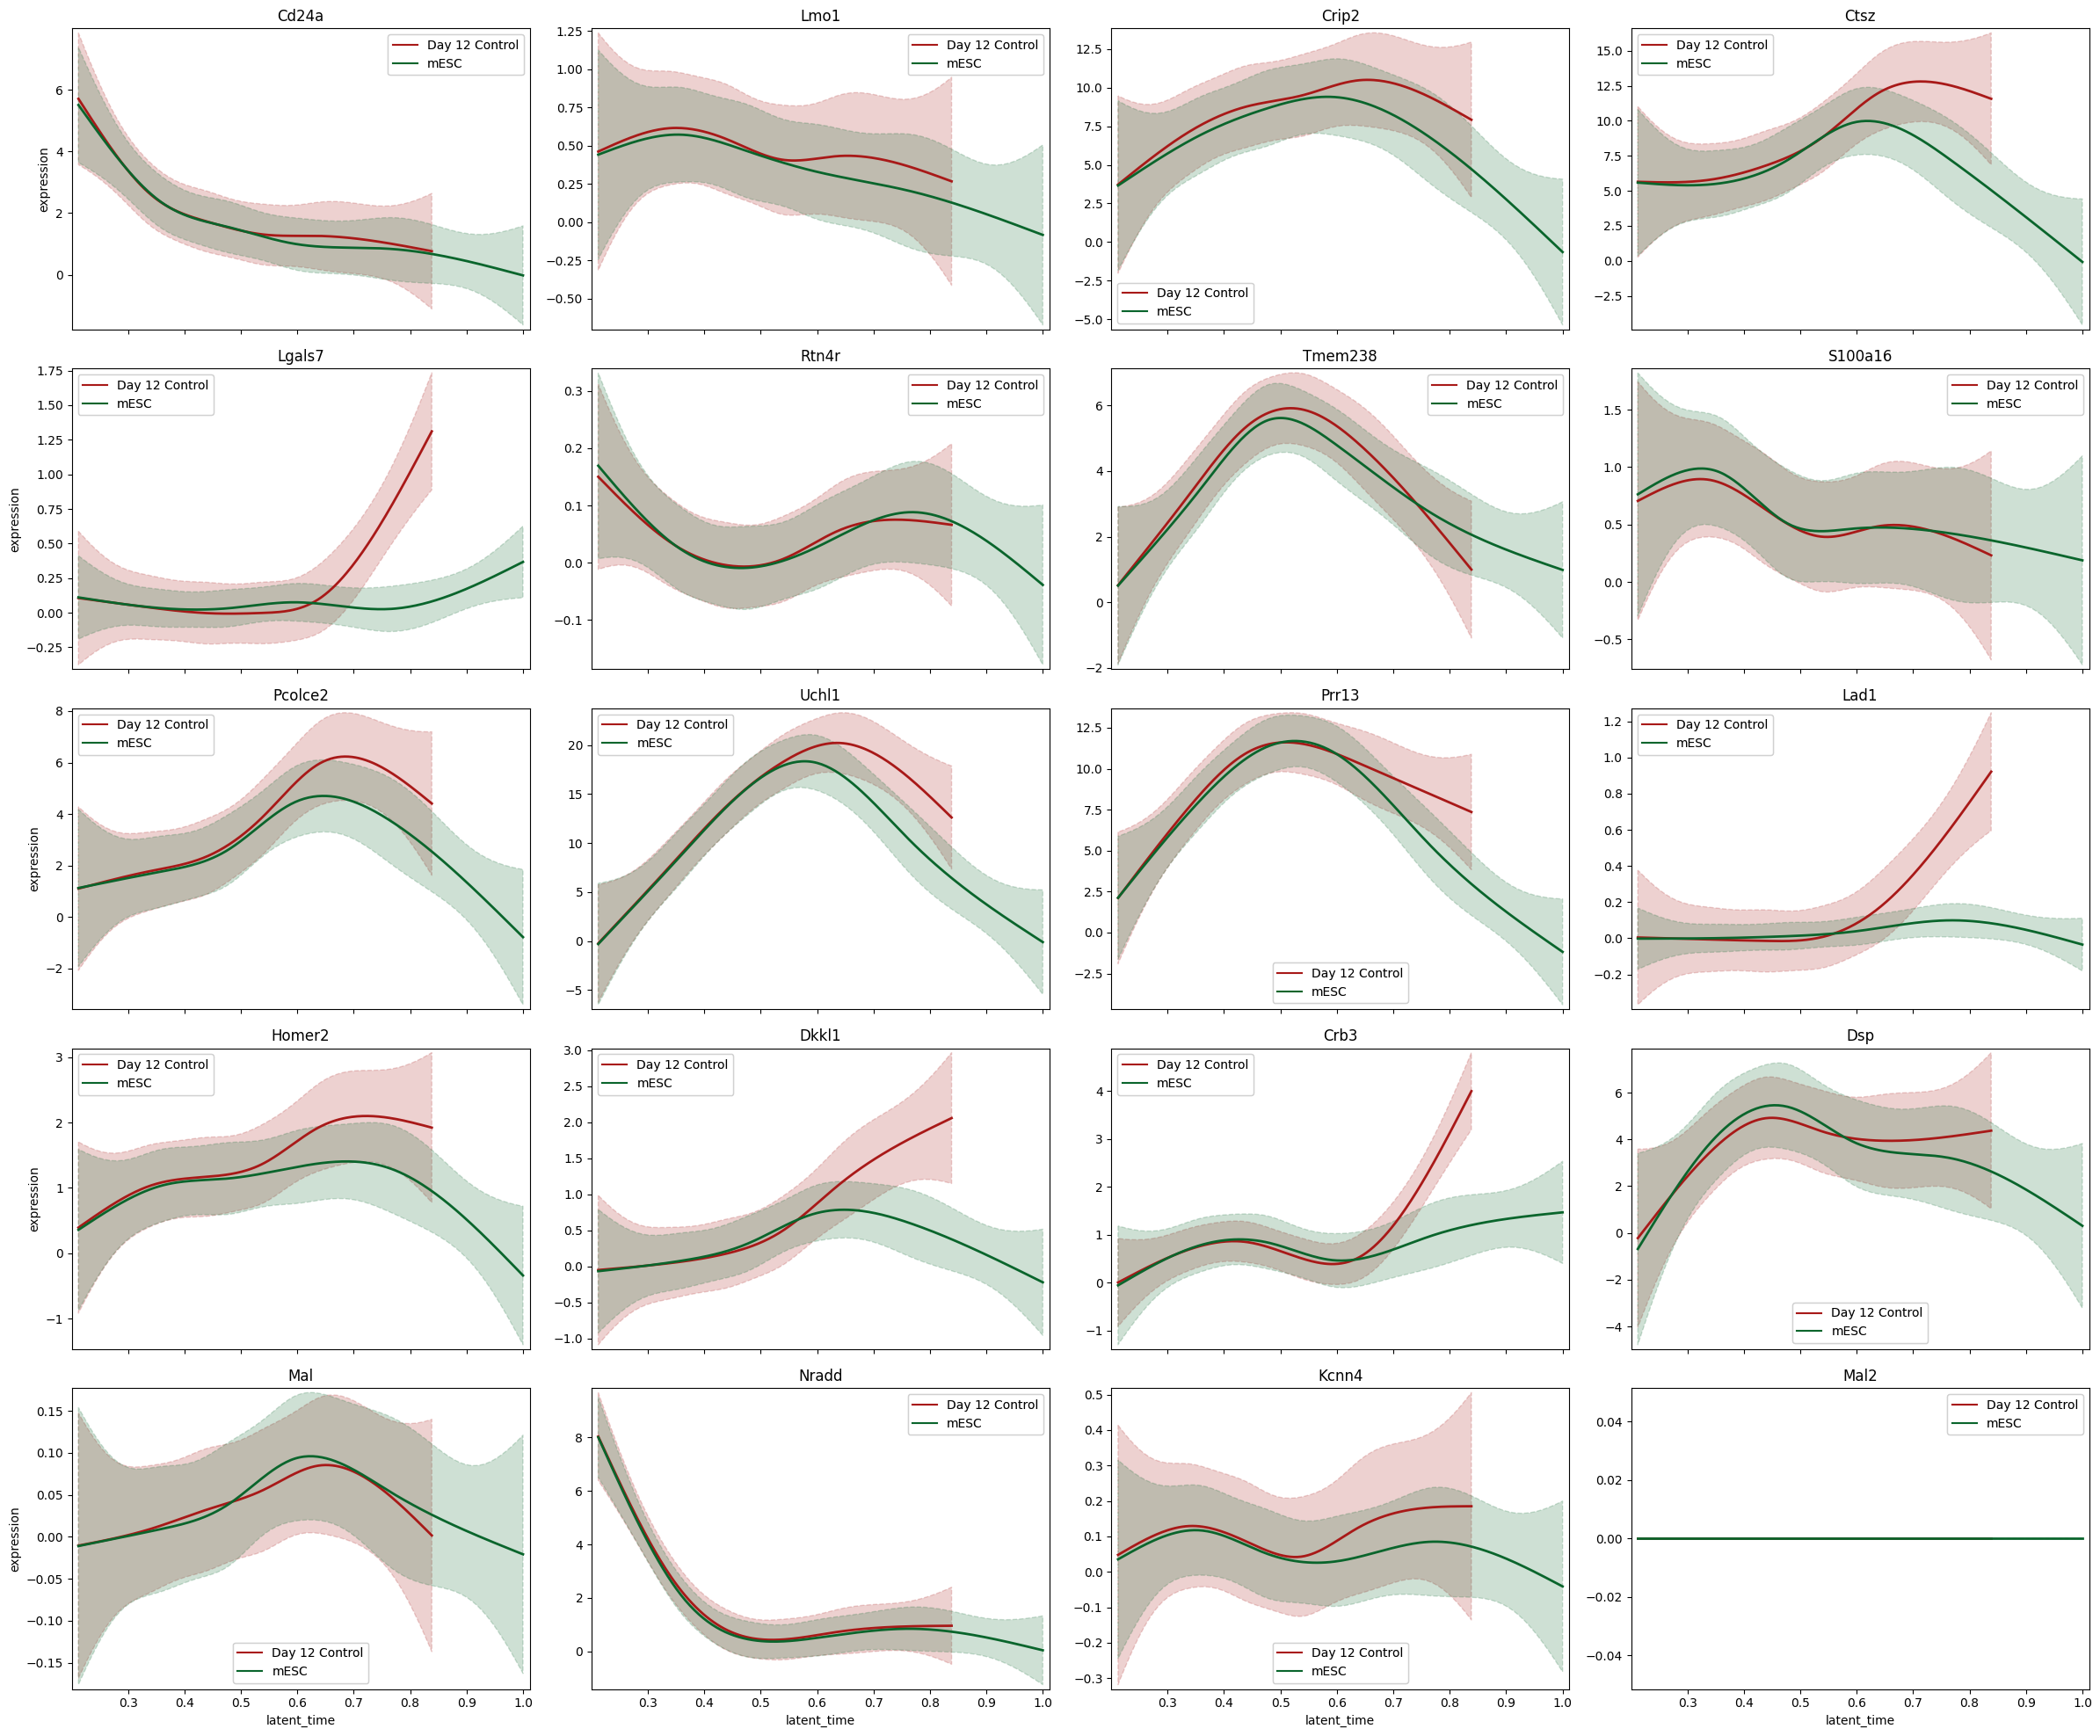

In [35]:
# Drivers with only Hic2

hic2_indices = adata.obs["group"] == "Hic2"
model = cellrank.models.GAMR(adata[hic2_indices], n_knots=6, smoothing_penalty=10.0)

dead_end = "Day 12 Control"
cellrank.pl.gene_trends(
    adata[hic2_indices],
    model=model,
    genes=driver_df.sort_values(f"{dead_end}_corr", ascending=False).head(20).index,
    data_key="spliced",
    same_plot=True,
    ncols=4,
    time_key="latent_time",
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)


  0%|          | 0/40 [00:00<?, ?gene/s]

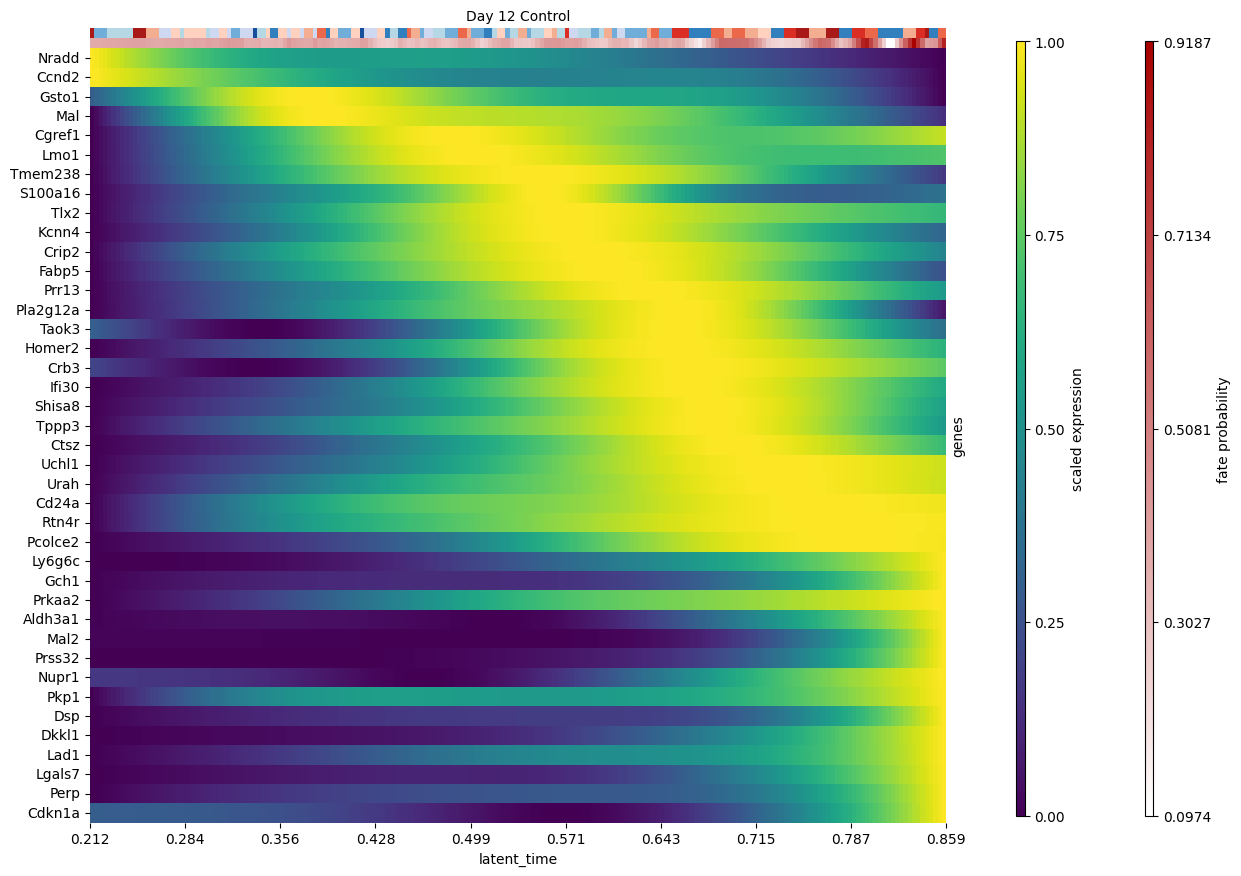

In [36]:
# Heatmap for dead-end related genes

model = cellrank.models.GAMR(adata[reprogramming_group_indices], n_knots=6, smoothing_penalty=10.0)
cellrank.pl.heatmap(
    adata[reprogramming_group_indices],
    model=model,  # use the model from before
    lineages=dead_end,
    cluster_key="sample",
    show_fate_probabilities=True,
    data_key="spliced",
    genes=driver_df.sort_values(f"{dead_end}_corr", ascending=False).head(40).index,
    time_key="latent_time",
    figsize=(12, 10),
    show_all_genes=True,
    weight_threshold=(1e-3, 1e-3),
)


  0%|          | 0/40 [00:00<?, ?gene/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


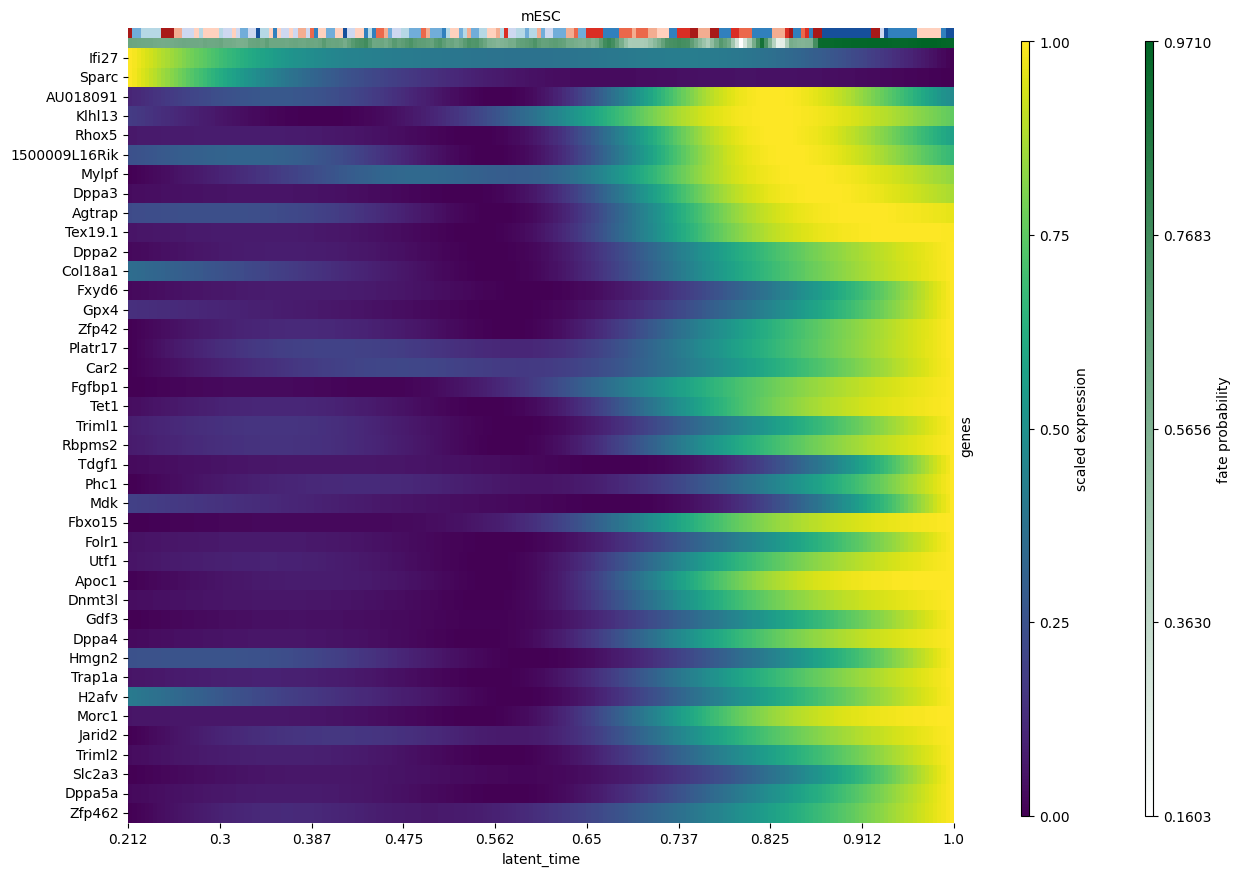

In [37]:
# Heatmap for completed reprogramming

terminal_state = "mESC"
model = cellrank.models.GAMR(adata[reprogramming_group_indices], n_knots=6, smoothing_penalty=10.0)
cellrank.pl.heatmap(
    adata[reprogramming_group_indices],
    model=model,  # use the model from before
    lineages=terminal_state,
    cluster_key="sample",
    show_fate_probabilities=True,
    data_key="spliced",
    genes=driver_df.sort_values(f"{terminal_state}_corr", ascending=False).head(40).index,
    time_key="latent_time",
    figsize=(12, 10),
    show_all_genes=True,
    weight_threshold=(1e-3, 1e-3),
)


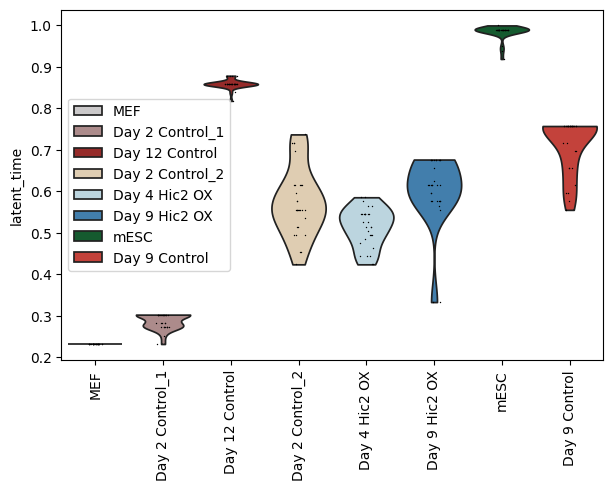

In [38]:
# Show macrostates in latent time

scanpy.pl.violin(adata, keys=["latent_time"], groupby="macrostates_fwd", rotation=90)

## GO analysis

In [40]:
# GO analysis

rank_data = driver_df[[f"{dead_end}_corr"]].sort_values(f"{dead_end}_corr", ascending=False).dropna()

# Run GSEA Prerank
pre_res = gseapy.prerank(
    rnk=rank_data, 
    gene_sets="GO_Biological_Process_2025",
    threads=16,
    min_size=5,
    max_size=1000,
    permutation_num=2000
)

print("Control drivers:")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=False).head(20))

print("mESC drivers:")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=True).head(20))

2026-01-28 16:13:13,815 [WARNING] Duplicated values found in preranked stats: 0.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Control drivers:


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Epidermis Development (GO:0008544),0.651752,1.823958,0.00243,0.736673,0.478,10/21,19.18%,Fabp5;Ovol1;Krt14;Crabp2;Spint1;Klk14;Gjb5;Emp...
1,prerank,Regulation of Trans-Synaptic Signaling (GO:009...,0.793331,1.805055,0.003546,0.488157,0.5755,2/10,5.41%,Fabp5;Dlgap1
2,prerank,Proteolysis Involved in Protein Catabolic Proc...,0.744086,1.759253,0.00601,0.611379,0.789,3/11,5.56%,Ctsz;Ctsb;Ctsc
3,prerank,Regulation of Glycolytic Process (GO:0006110),0.816583,1.739484,0.004884,0.6001,0.856,5/8,12.32%,Uchl1;Nupr1;Prkaa2;Cbfa2t3;App
5,prerank,Antigen Processing and Presentation of Exogeno...,0.857518,1.697311,0.002364,0.588514,0.954,1/6,1.35%,Ifi30
6,prerank,Antigen Processing and Presentation of Peptide...,0.857518,1.697311,0.002364,0.588514,0.954,1/6,1.35%,Ifi30
7,prerank,Antigen Processing and Presentation of Exogeno...,0.857518,1.697311,0.002364,0.588514,0.954,1/6,1.35%,Ifi30
11,prerank,Negative Regulation of Myeloid Leukocyte Diffe...,0.762549,1.619324,0.027947,1.0,0.9975,4/8,14.17%,Myc;Hoxa7;Runx1;Fbn1
13,prerank,Positive Regulation of Glycolytic Process (GO:...,0.871311,1.612436,0.014201,1.0,0.9985,2/5,1.75%,Uchl1;Prkaa2
12,prerank,Positive Regulation of Purine Nucleotide Catab...,0.871311,1.612436,0.014201,1.0,0.9985,2/5,1.75%,Uchl1;Prkaa2


mESC drivers:


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
4,prerank,Chromatin Organization (GO:0006325),-0.645149,-1.735201,0.000786,1.0,0.53,14/25,15.17%,Hmgn2;Jarid2;Tet1;Phc1;Tcf7l1;Rest;Hmgb2;Sycp3...
8,prerank,Protein Polyubiquitination (GO:0000209),-0.73128,-1.681702,0.004216,1.0,0.7915,7/13,15.17%,Ifi27;Arrdc4;Nedd4;Trim71;Mkrn1;Rnf31;Brca1
9,prerank,DNA Metabolic Process (GO:0006259),-0.645582,-1.645704,0.00665,1.0,0.9245,11/19,16.32%,Msh6;Hmgb2;Terf1;Top2a;Mcm3;Rec114;Tcf7l2;Horm...
10,prerank,Male Meiotic Nuclear Division (GO:0007140),-0.917477,-1.640251,0.000862,1.0,0.9365,4/5,8.46%,Dnmt3l;Tdrd12;Sycp3;Hsf2bp
14,prerank,Transcription by RNA Polymerase II (GO:0006366),-0.780307,-1.608396,0.006683,1.0,0.981,4/9,8.71%,Taf7;Anxa2;Hsf2bp;Tsc22d1
16,prerank,Regulation of Insulin Secretion (GO:0050796),-0.768465,-1.597013,0.010989,1.0,0.99,4/9,18.73%,Rest;Sfrp1;Tcf7l2;Trh
17,prerank,Transcription Initiation-Coupled Chromatin Rem...,-0.862107,-1.596662,0.003552,1.0,0.9905,3/6,5.16%,Tet1;Ash2l;Apobec2
20,prerank,Regulation of Viral Genome Replication (GO:004...,-0.671474,-1.586008,0.015319,1.0,0.994,7/14,22.23%,Ifitm1;Ifitm3;Fam111a;Isg15;Fkbp6;Bst2;Nr5a2
23,prerank,Visual System Development (GO:0150063),-0.782429,-1.577949,0.015571,1.0,0.996,1/8,0.45%,Gdf3
27,prerank,Regulation of Cholesterol Efflux (GO:0010874),-0.822147,-1.539092,0.0103,1.0,1.0,4/6,12.07%,Apoe;Pla2g10;Ptch1;Pltp


In [42]:
# Less detailed enrichment analysis

rank_data = driver_df[[f"{dead_end}_corr"]].sort_values(f"{dead_end}_corr", ascending=False).dropna()

# Run GSEA Prerank
pre_res = gseapy.prerank(
    rnk=rank_data, 
    gene_sets="MSigDB_Hallmark_2020",
    threads=16,
    min_size=5,
    max_size=1000,
    permutation_num=2000
)

print("Control drivers:")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=False).head(20)[["Term", "ES", "NES", "NOM p-val", "FWER p-val", "FDR q-val"]]) # Top Day 12

print("mESC drivers:")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=True).head(20)[["Term", "ES", "NES", "NOM p-val", "FWER p-val", "FDR q-val"]]) # Top Day 12

2026-01-28 16:14:29,131 [WARNING] Duplicated values found in preranked stats: 0.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Control drivers:


,Term,ES,NES,NOM p-val,FWER p-val,FDR q-val
0,p53 Pathway,0.465867,1.622348,0.002886,0.191,0.396618
2,Estrogen Response Early,0.465327,1.581142,0.005814,0.261,0.289298
3,Cholesterol Homeostasis,0.521232,1.516331,0.024902,0.4025,0.320405
5,Androgen Response,0.50068,1.459519,0.046768,0.5345,0.362089
9,Estrogen Response Late,0.404895,1.385188,0.032738,0.698,0.466237
11,Allograft Rejection,0.425585,1.352252,0.074965,0.759,0.470187
12,Unfolded Protein Response,0.5849,1.330619,0.156438,0.797,0.451678
14,IL-2/STAT5 Signaling,0.369723,1.283723,0.077241,0.8645,0.515954
15,Wnt-beta Catenin Signaling,0.601385,1.251491,0.218293,0.9055,0.542097
16,mTORC1 Signaling,0.396849,1.249632,0.119681,0.9075,0.49218


mESC drivers:


,Term,ES,NES,NOM p-val,FWER p-val,FDR q-val
1,G2-M Checkpoint,-0.552405,-1.6174,0.003135,0.17,0.09112
4,Spermatogenesis,-0.666941,-1.465716,0.064167,0.584,0.224633
6,DNA Repair,-0.721928,-1.401766,0.069231,0.7725,0.259555
7,Oxidative Phosphorylation,-0.719998,-1.401497,0.071303,0.7735,0.195031
8,Mitotic Spindle,-0.472249,-1.393688,0.051506,0.7905,0.166307
10,E2F Targets,-0.496278,-1.38118,0.061453,0.82,0.152801
13,Interferon Alpha Response,-0.438438,-1.286609,0.113338,0.9605,0.255506
25,Adipogenesis,-0.354067,-1.026155,0.40708,1.0,0.79045
30,Bile Acid Metabolism,-0.421267,-0.931653,0.570707,1.0,0.963097
31,Interferon Gamma Response,-0.258691,-0.832046,0.785875,1.0,1.0


In [ ]:
# Cell types

rank_data = driver_df[[f"{dead_end}_corr"]].sort_values(f"{dead_end}_corr", ascending=False).dropna()

# Run GSEA Prerank
pre_res = gseapy.prerank(
    rnk=rank_data, 
    gene_sets="PanglaoDB_Augmented_2021",
    threads=16,
    min_size=5,
    max_size=1000,
    permutation_num=2000
)

print("Control drivers:")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=False).head(20)[["Term", "ES", "NES", "NOM p-val", "FWER p-val", "FDR q-val"]]) # Top Day 12

print("mESC drivers:")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=True).head(20)[["Term", "ES", "NES", "NOM p-val", "FWER p-val", "FDR q-val"]]) # Top Day 12

2026-01-28 16:14:54,493 [WARNING] Duplicated values found in preranked stats: 0.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Control drivers:


,Term,ES,NES,NOM p-val,FWER p-val,FDR q-val
0,Salivary Mucous Cells,0.74047,2.246286,0.0,0.0005,0.000666
1,Gastric Chief Cells,0.811901,2.221336,0.0,0.0005,0.000333
2,Mammary Epithelial Cells,0.637421,2.048073,0.0,0.0055,0.002443
3,Cholangiocytes,0.688711,2.011688,0.0,0.01,0.003497
4,Keratinocytes,0.624155,1.999555,0.0,0.012,0.003331
5,Luminal Epithelial Cells,0.619293,1.966768,0.0,0.0165,0.003997
6,Foveolar Cells,0.72034,1.958138,0.0,0.0195,0.003997
8,Urothelial Cells,0.786346,1.938493,0.0,0.025,0.004497
9,Microfold Cells,0.597855,1.936963,0.001337,0.025,0.003997
10,Sebocytes,0.635116,1.910656,0.0,0.0335,0.00493


mESC drivers:


,Term,ES,NES,NOM p-val,FWER p-val,FDR q-val
7,Pluripotent Stem Cells,-0.7223,-1.940698,0.0,0.005,0.004038
20,Epiblast Cells,-0.59861,-1.706831,0.002383,0.1755,0.089038
23,Gamma Delta T Cells,-0.698594,-1.581924,0.016708,0.5755,0.30231
24,Embryonic Stem Cells,-0.484307,-1.574322,0.005339,0.6065,0.248841
27,Oxyphil Cells,-0.598702,-1.466164,0.045939,0.904,0.561118
29,Adrenergic Neurons,-0.644803,-1.417527,0.070529,0.9635,0.699648
30,Myocytes,-0.474071,-1.412231,0.04232,0.9685,0.625195
32,Ependymal Cells,-0.619867,-1.392856,0.078481,0.981,0.633206
38,Osteocytes,-0.428003,-1.338772,0.066926,0.996,0.834113
39,Microglia,-0.428204,-1.292072,0.101072,0.999,1.0


In [44]:
# Get libraries

panglao_lib = gseapy.get_library(name='PanglaoDB_Augmented_2021', organism='Mouse')
go_lib = gseapy.get_library(name='GO_Biological_Process_2025', organism='Mouse')
hallmark_lib = gseapy.get_library(name='MSigDB_Hallmark_2020', organism='Mouse')

In [46]:
# Specific gene groups
target_sets = {
    "Apoptosis Activation": go_lib["Positive Regulation of Apoptotic Process (GO:0043065)"],
    "Apoptosis Inhibition": go_lib["Negative Regulation of Apoptotic Process (GO:0043066)"],
    "Cell Cycle Inhibition": go_lib["Negative Regulation of Cell Cycle (GO:0045786)"],
    "Cell Cycle Activation": go_lib["Positive Regulation of Cell Cycle (GO:0045787)"],
    "Apoptosis Signaling Inhibition": go_lib["Negative Regulation of Apoptotic Signaling Pathway (GO:2001234)"],
    "Apoptosis Signaling Activation": go_lib["Positive Regulation of Apoptotic Signaling Pathway (GO:2001235)"],
    "Stem Cell Proliferation": go_lib["Positive Regulation of Stem Cell Proliferation (GO:2000648)"],
    "Stem Cell Inhibited Proliferation": go_lib["Negative Regulation of Stem Cell Population Maintenance (GO:1902455)"],
    "Stem Cell Inhibited Differentiation": go_lib["Negative Regulation of Stem Cell Differentiation (GO:2000737)"],
    "Stem Cell Differentiation": go_lib["Positive Regulation of Stem Cell Differentiation (GO:2000738)"],
    "DNA Damage Response": go_lib["DNA Damage Response (GO:0006974)"],
    "DNA_Repair": hallmark_lib['DNA Repair'],
    "P53_Pathway": hallmark_lib['p53 Pathway'],
    "Keratinocytes": panglao_lib["Keratinocytes"],
    "Epithelial cells": panglao_lib["Epithelial Cells"]
}

rank_data = driver_df[[f"{dead_end}_corr"]].sort_values(f"{dead_end}_corr", ascending=False).dropna()

# Run GSEA Prerank
pre_res = gseapy.prerank(
    rnk=rank_data, 
    gene_sets=target_sets,
    threads=16,
    min_size=5,
    max_size=2000,
    permutation_num=1000,
    seed=0
)

pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-01-28 16:15:43,460 [WARNING] Duplicated values found in preranked stats: 0.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Keratinocytes,0.624155,2.029846,0.0,0.0,0.0,21/41,15.82%,Lgals7;Lad1;Pkp1;Perp;Ovol1;Anxa8;S100a14;Krt1...
1,prerank,Epithelial cells,0.541114,1.915319,0.0,0.001823,0.003,32/67,19.08%,Lad1;Crb3;Mal2;Ovol1;Krt8;Dgat2;Gpx2;Misp;S100...
2,prerank,P53_Pathway,0.465867,1.61886,0.00304,0.031193,0.075,24/60,18.48%,Ccnd2;Ifi30;Nupr1;Perp;Cdkn1a;Sat1;Gpx2;Krt17;...
3,prerank,Apoptosis Signaling Activation,0.656891,1.582611,0.026379,0.029471,0.094,5/11,16.68%,Nupr1;Bbc3;App;Tnfrsf12a;Ddit3
7,prerank,Apoptosis Inhibition,0.210934,0.807393,0.939799,0.946243,0.98,18/107,15.12%,Ccnd2;Nupr1;Prkaa2;Cd44;Myc;Anxa5;Tmbim1;Ddah2...
10,prerank,Cell Cycle Inhibition,0.281075,0.685549,0.899471,0.921207,0.995,1/14,1.40%,Nupr1
12,prerank,Apoptosis Signaling Inhibition,-0.238387,-0.561535,0.983607,0.988838,1.0,4/14,33.15%,Tcf7l2;Bmp4;Thbs1;Clu
11,prerank,Stem Cell Proliferation,-0.284124,-0.575769,0.977663,1.0,1.0,1/8,7.46%,Nanog
9,prerank,Cell Cycle Activation,-0.289297,-0.702135,0.887772,1.0,1.0,2/16,5.01%,Tcf7l1;Cited2
8,prerank,Apoptosis Activation,-0.241215,-0.767273,0.899848,1.0,0.999,29/63,37.71%,Dlc1;Rest;Gadd45b;Top2a;Bnip3;Tsc22d1;Sfrp1;Ec...


# Save results

In [ ]:
# Save results

# base_name = "cellrank_1.3"

# adata.write_h5ad(
#     working_directory+f"/{base_name} cells.h5ad",
#     compression=hdf5plugin.FILTERS["zstd"]
# )

# dead_end_adata.write_h5ad(
#     working_directory+f"/{base_name} dead end genes.h5ad",
#     compression=hdf5plugin.FILTERS["zstd"]
# )

# mESC_adata.write_h5ad(
#     working_directory+f"/{base_name} mESC genes.h5ad",
#     compression=hdf5plugin.FILTERS["zstd"]
# )

# driver_df.to_csv(
#     working_directory+f"{base_name} driver genes.csv",
# )